# Affine Calibration of Model-Implied CDS Spreads

## Methodology

Structural credit-risk models (Merton/GARCH/Regime-Switching/MS-GARCH) produce *model-implied* CDS spreads $s_{i,t}^{(m)}(\tau)$ that may differ from *observed market* spreads $S_{i,t}^{\text{CDS}}(\tau)$ in both **level** and **scale**.

To correct for this, we implement a **rolling affine calibration** for each model $m$ and maturity $\tau \in \{1, 3, 5\}$ years.

### In-Sample Estimation
At each evaluation date $t$, parameters are estimated over a rolling window of length $W = 52$ weeks (≈ 260 trading days):

$$S_{i,t-k}^{\text{CDS}}(\tau) = \beta_0^{(m,\tau)}(t) + \beta_1^{(m,\tau)}(t)\, s_{i,t-k}^{(m)}(\tau) + u_{i,t-k}, \quad k = 1, \ldots, W$$

The OLS estimator at date $t$ is:

$$\hat{\boldsymbol{\beta}}^{(m,\tau)}(t) = \begin{pmatrix} \hat{\beta}_0^{(m,\tau)}(t) \\ \hat{\beta}_1^{(m,\tau)}(t) \end{pmatrix} = (X_t'X_t)^{-1} X_t' y_t$$

### Out-of-Sample Application
The calibrated (out-of-sample) model-implied spread is:

$$\hat{s}_{i,t}^{(m)}(\tau) = \hat{\beta}_0^{(m,\tau)}(t) + \hat{\beta}_1^{(m,\tau)}(t)\, s_{i,t}^{(m)}(\tau)$$

Because calibration parameters use only information up to $t-1$, the calibrated spread $\hat{s}_{i,t}^{(m)}(\tau)$ is a **strictly out-of-sample** prediction.

---

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# Resolve project root robustly:
# This notebook lives in  <project_root>/notebooks/calibration_analysis.ipynb
# so the project root is always one level above this file.
try:
    # Works when the notebook is opened as a file (most common)
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    # Fallback: use cwd and walk upward until we find the 'src' directory
    NOTEBOOK_DIR = Path.cwd()
    for candidate in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
        if (candidate / 'src').exists():
            NOTEBOOK_DIR = candidate / 'notebooks'
            break

PROJECT_ROOT = NOTEBOOK_DIR.parent  # notebooks/ -> Seminar QF/
if not (PROJECT_ROOT / 'src').exists():
    # last-resort: search upward from cwd
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'src').exists():
            PROJECT_ROOT = candidate
            break

# Put project root on sys.path so 'src' is importable
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Paths
OUTPUT_DIR  = PROJECT_ROOT / 'data' / 'output'
INPUT_DIR   = PROJECT_ROOT / 'data' / 'input'
MERTON_FILE = OUTPUT_DIR / 'merged_data_with_merton.csv'
CALIB_DIR   = OUTPUT_DIR / 'calibration'
CALIB_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root : {PROJECT_ROOT}')
print(f'src exists   : {(PROJECT_ROOT / "src").exists()}')
print(f'Output dir   : {OUTPUT_DIR}')
print(f'Input dir    : {INPUT_DIR}')
print(f'Calibration  : {CALIB_DIR}')


Project root : c:\Users\Chase\Downloads\Seminar QF\Seminar QF
src exists   : True
Output dir   : c:\Users\Chase\Downloads\Seminar QF\Seminar QF\data\output
Input dir    : c:\Users\Chase\Downloads\Seminar QF\Seminar QF\data\input
Calibration  : c:\Users\Chase\Downloads\Seminar QF\Seminar QF\data\output\calibration


In [2]:
# Import the self-contained calibration module
# (reload to pick up any source edits made between runs)
import importlib, src.calibration.affine_calibration, src.calibration.calibration_plots
importlib.reload(src.calibration.affine_calibration)
importlib.reload(src.calibration.calibration_plots)

from src.calibration.affine_calibration import (
    calibrate_model,
    compute_metrics,
    compute_firm_level_metrics,
    DEFAULT_WINDOW_DAYS,
    MODEL_CONFIGS,
    MATURITIES,
)
from src.calibration.calibration_plots import (
    plot_timeseries,
    plot_scatter_comparison,
    plot_rolling_betas,
    plot_rmse_comparison,
    metrics_summary_table,
    plot_mean_median_vs_market,
    plot_mean_median_by_leverage,
)

print(f'Estimation window : {DEFAULT_WINDOW_DAYS} trading days  '
      f'(≈ {DEFAULT_WINDOW_DAYS // 5} weeks)')
print(f'Models available  : {list(MODEL_CONFIGS.keys())}')
print(f'Maturities        : {MATURITIES}')

Estimation window : 252 trading days  (≈ 50 weeks)
Models available  : ['GARCH', 'Regime-Switching', 'MS-GARCH']
Maturities        : [1, 3, 5]


---
## 1. Run Calibration for All Models

For each model we:
1. Load the Monte Carlo–implied spreads and convert them from decimal to basis points.
2. Merge with market CDS data.
3. Run the rolling OLS calibration per (firm, maturity).

In [3]:
# Store all results and metrics
all_results = {}   # {model: {maturity: DataFrame}}
all_metrics = {}   # {model: {maturity: metrics_dict}}

for model_name in MODEL_CONFIGS:
    mc_file = OUTPUT_DIR / MODEL_CONFIGS[model_name]['mc_file']
    if not mc_file.exists():
        print(f'\n⚠  Skipping {model_name}: {mc_file.name} not found.')
        continue

    print(f'\n{"="*60}')
    print(f'  Calibrating: {model_name}')
    print(f'{"="*60}')

    results = calibrate_model(
        model_name=model_name,
        output_dir=OUTPUT_DIR,
        input_dir=INPUT_DIR,
        merton_file=MERTON_FILE,
        window=DEFAULT_WINDOW_DAYS,
        convert_model_to_bps=True,
    )
    all_results[model_name] = results

    # Compute aggregate metrics per maturity
    model_metrics = {}
    for mat_key, cal_df in results.items():
        model_metrics[mat_key] = compute_metrics(cal_df)
    all_metrics[model_name] = model_metrics

print('\n✓ Calibration complete for all available models.')


  Calibrating: GARCH
Loading model data from daily_monte_carlo_garch_results.csv ...
Loading market CDS data ...
Matched 164,895 firm-date-maturity observations across 29 firms.
  1y: 22,151 calibrated out-of-sample observations across 29 firms
  3y: 41,896 calibrated out-of-sample observations across 29 firms
  5y: 46,497 calibrated out-of-sample observations across 29 firms

  Calibrating: Regime-Switching
Loading model data from daily_monte_carlo_regime_switching_results.csv ...
Loading market CDS data ...
Matched 163,635 firm-date-maturity observations across 29 firms.
  1y: 21,823 calibrated out-of-sample observations across 29 firms
  3y: 40,146 calibrated out-of-sample observations across 29 firms
  5y: 45,635 calibrated out-of-sample observations across 29 firms

  Calibrating: MS-GARCH
Loading model data from daily_monte_carlo_ms_garch_results.csv ...
Loading market CDS data ...
Matched 164,895 firm-date-maturity observations across 29 firms.
  1y: 29,303 calibrated out-of-sa

---
## 2. Overall Metrics Summary

Compare RMSE and correlation **before** (raw) and **after** (calibrated) the affine transformation.

In [4]:
summary = metrics_summary_table(all_metrics)

# Display a nicely formatted table
display_cols = [
    'Model', 'Maturity',
    'rmse_raw', 'rmse_calibrated',
    'mae_raw', 'mae_calibrated',
    'corr_levels_raw', 'corr_levels_cal',
    'corr_changes_raw', 'corr_changes_cal',
    'mean_beta0', 'mean_beta1',
]
display_cols = [c for c in display_cols if c in summary.columns]
summary_display = summary[display_cols].copy()

# Round for readability
for c in summary_display.columns:
    if summary_display[c].dtype in ['float64', 'float32']:
        summary_display[c] = summary_display[c].round(4)

print('Calibration Metrics Summary')
print('=' * 80)
display(summary_display)

# Save to CSV
summary_display.to_csv(CALIB_DIR / 'calibration_metrics_summary.csv', index=False)
print(f'\nSaved to {CALIB_DIR / "calibration_metrics_summary.csv"}')

Calibration Metrics Summary


,Model,Maturity,rmse_raw,rmse_calibrated,mae_raw,mae_calibrated,corr_levels_raw,corr_levels_cal,corr_changes_raw,corr_changes_cal,mean_beta0,mean_beta1
0,GARCH,1y,865.2518,24.0777,172.5191,5.5937,0.3601,0.4127,0.0073,0.0033,15.7083,5.7279
1,GARCH,3y,788.7148,18.8890,190.3700,7.1079,0.2656,0.7035,0.0210,0.0061,25.8171,11.6252
2,GARCH,5y,566.2342,57.6049,157.4055,9.3152,0.1816,0.4565,0.0291,-0.0041,41.0467,8.4567
3,Regime-Switching,1y,1029.7226,21.2982,318.7140,5.0367,0.4003,0.4635,0.0082,0.0133,10.0834,5.0028
4,Regime-Switching,3y,1071.2732,492.0184,382.5249,9.7558,0.3044,0.0440,0.0141,-0.0146,19.5880,10.9984
5,Regime-Switching,5y,993.9578,155.6596,404.5911,9.9647,0.2648,0.1829,0.0330,-0.0134,27.2018,8.0938
6,MS-GARCH,1y,946.5600,16.3809,223.0345,5.2845,0.4338,0.5149,0.0125,-0.0017,16.1773,0.6818
7,MS-GARCH,3y,979.1110,85.5239,291.5873,8.9343,0.3272,0.1939,0.0164,-0.0184,29.1976,1.1410
8,MS-GARCH,5y,835.8939,65.1684,276.4526,11.4188,0.2338,0.3634,0.0315,-0.0164,49.0239,0.7932



Saved to c:\Users\Chase\Downloads\Seminar QF\Seminar QF\data\output\calibration\calibration_metrics_summary.csv


---
## 3. RMSE Comparison Bar Chart

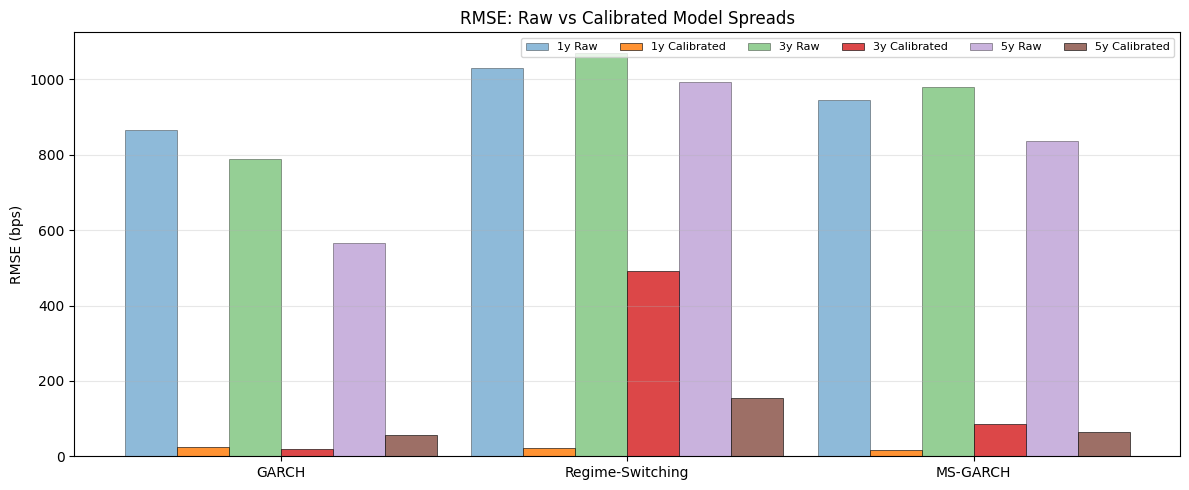

In [5]:
plot_rmse_comparison(
    all_metrics,
    save_path=str(CALIB_DIR / 'rmse_raw_vs_calibrated.png'),
)

---
## 4. Scatter Plots: Raw vs Calibrated (5-Year Maturity)

Side-by-side scatter plots for each model, showing how the calibration moves model spreads
closer to the 45° line.

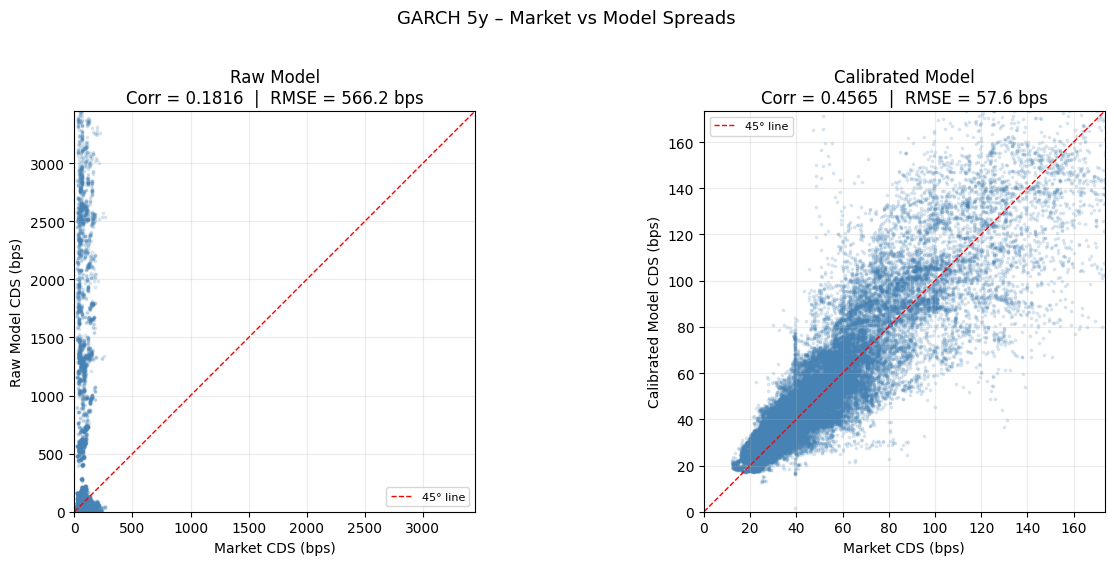

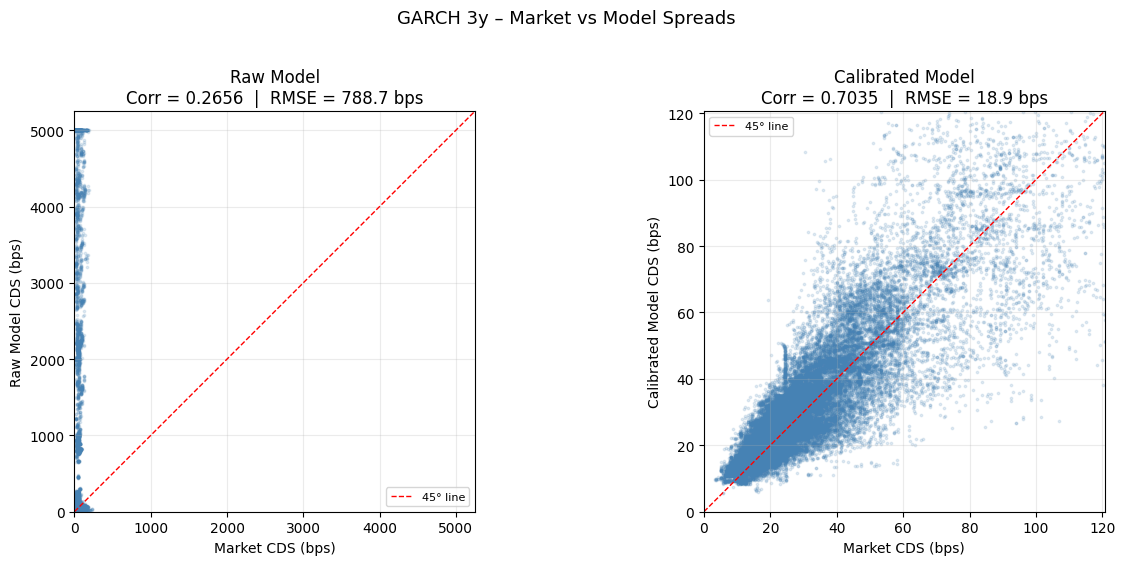

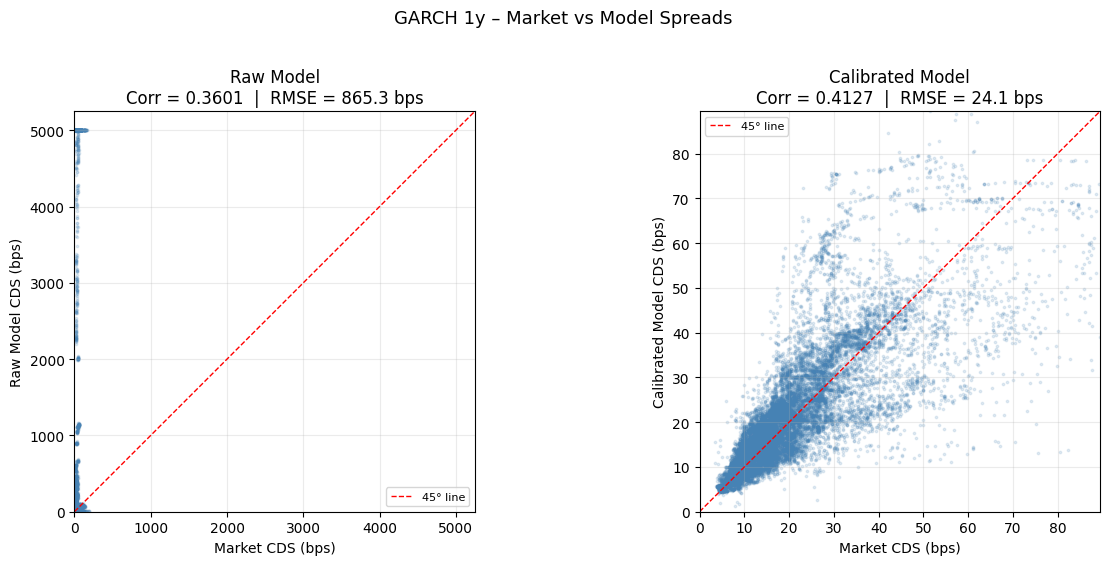

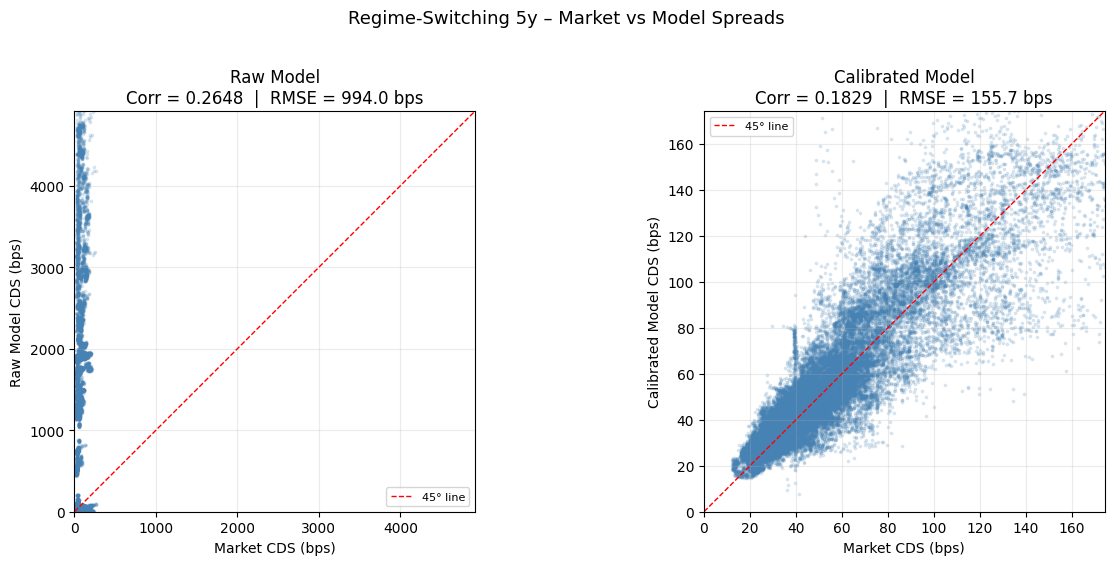

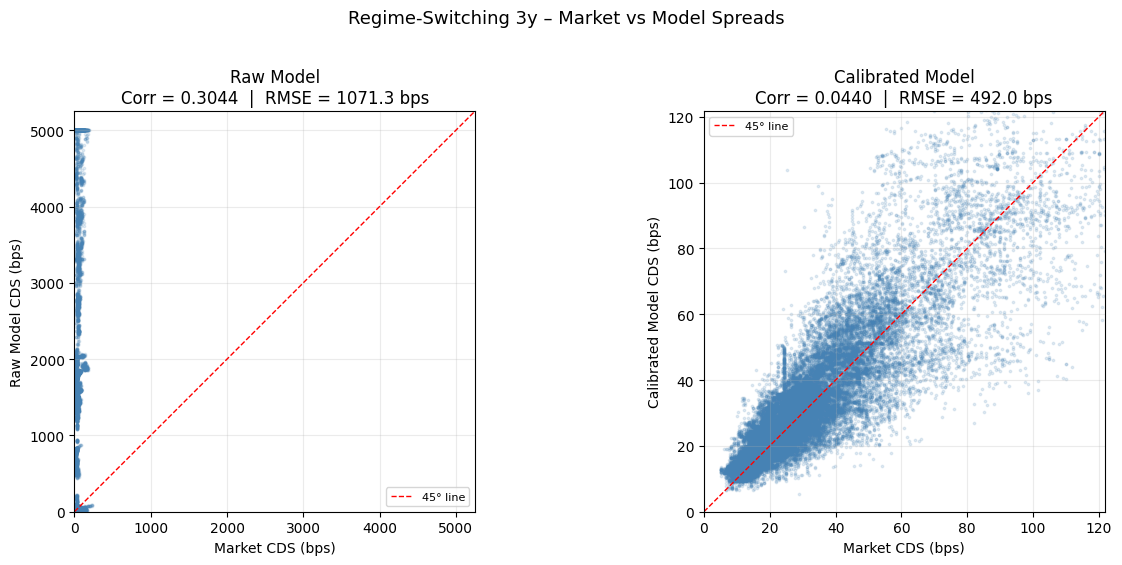

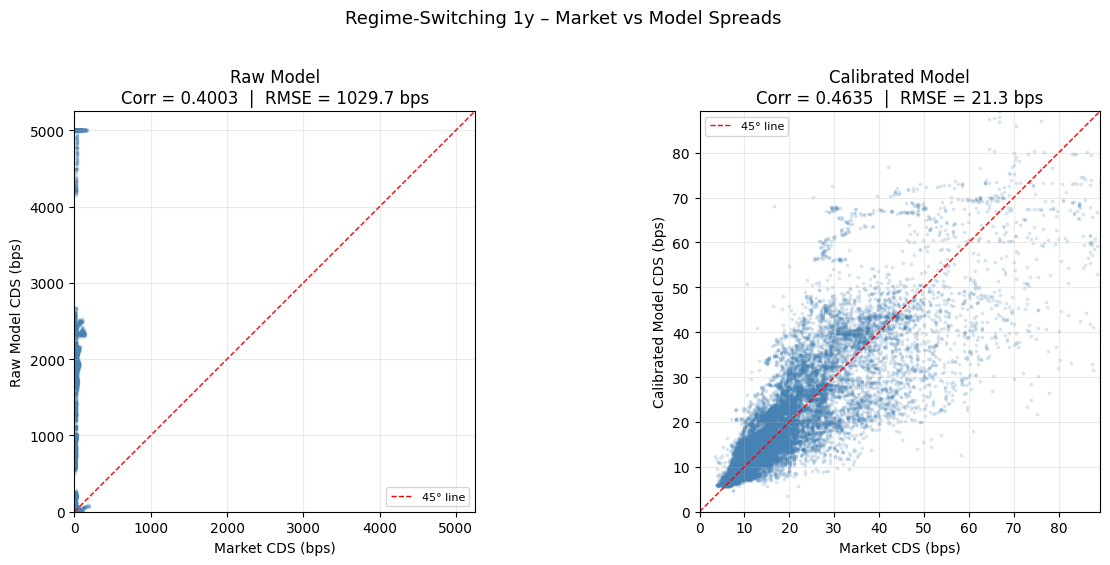

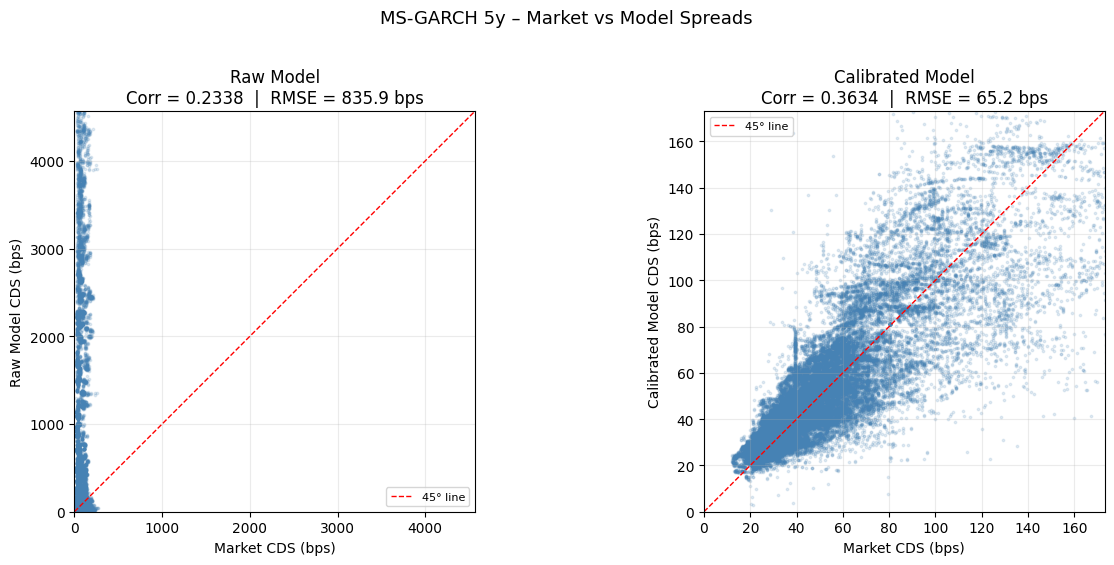

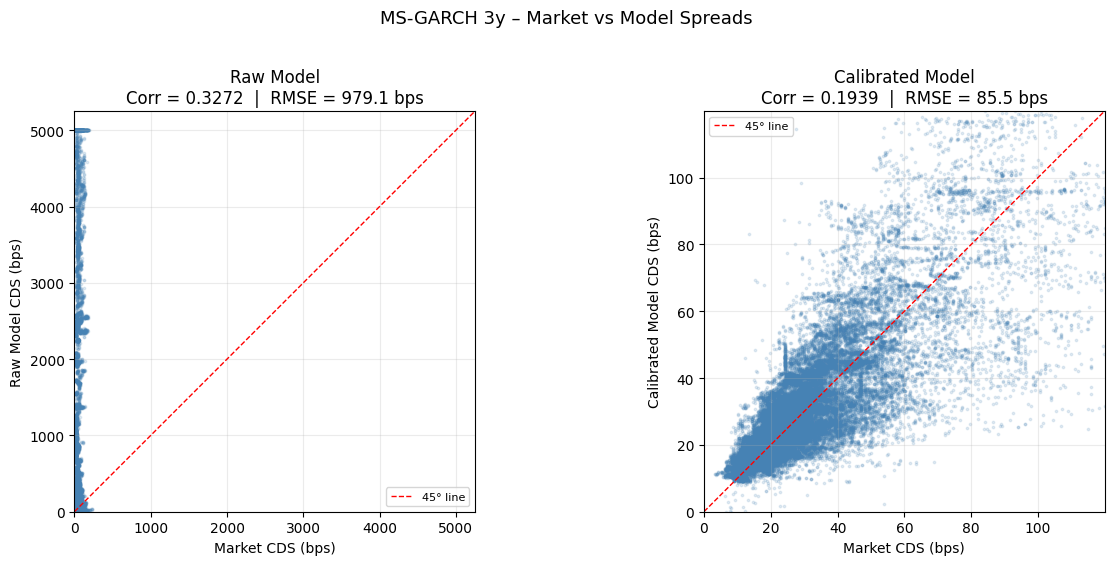

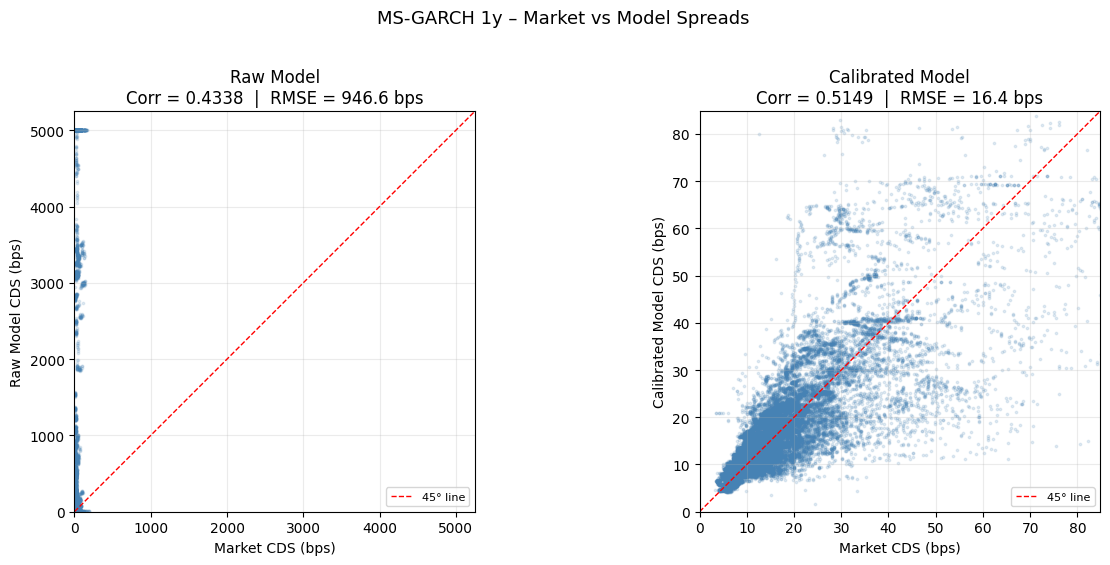

In [6]:
for model_name, results in all_results.items():
    for mat_key in ['5y', '3y', '1y']:
        if mat_key in results:
            plot_scatter_comparison(
                results[mat_key],
                model_name=model_name,
                maturity=mat_key,
                save_path=str(CALIB_DIR / f'scatter_{model_name.lower().replace("-", "_")}_{mat_key}.png'),
            )

---
## 5. Time-Series Examples

Plot raw model, calibrated model, and market spreads over time for selected firms.

Showing GARCH 5y for firms: [14447, 15532, 15549, 15677]



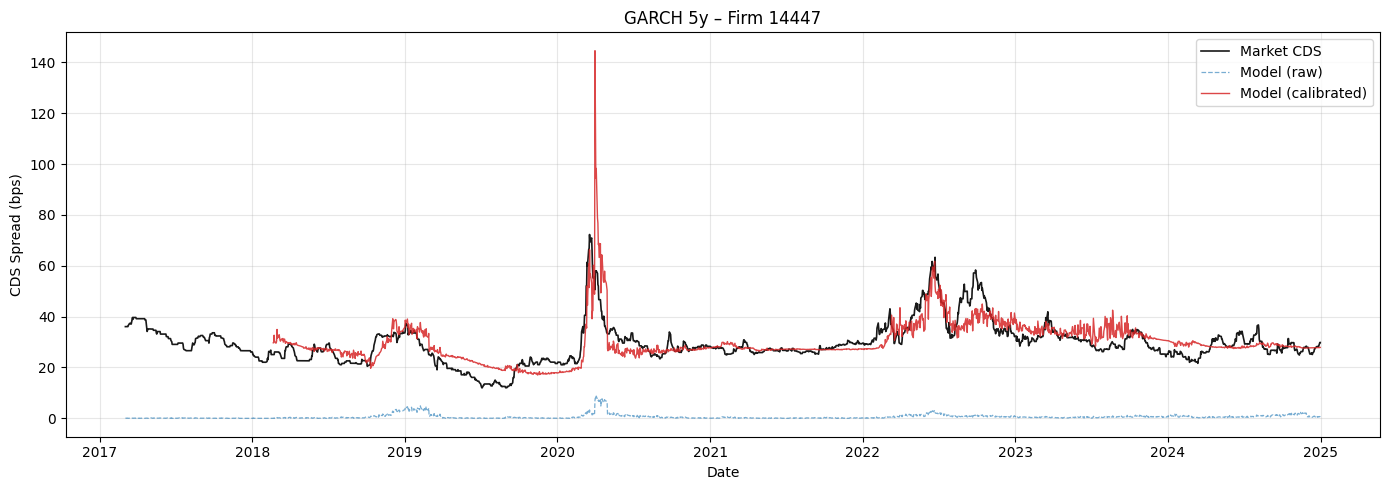

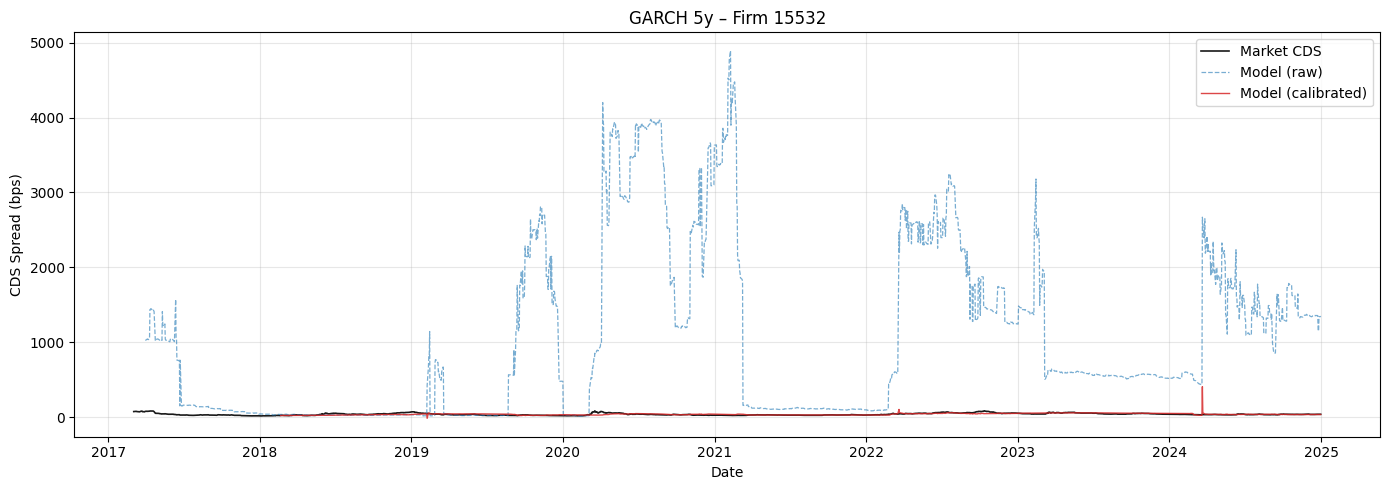

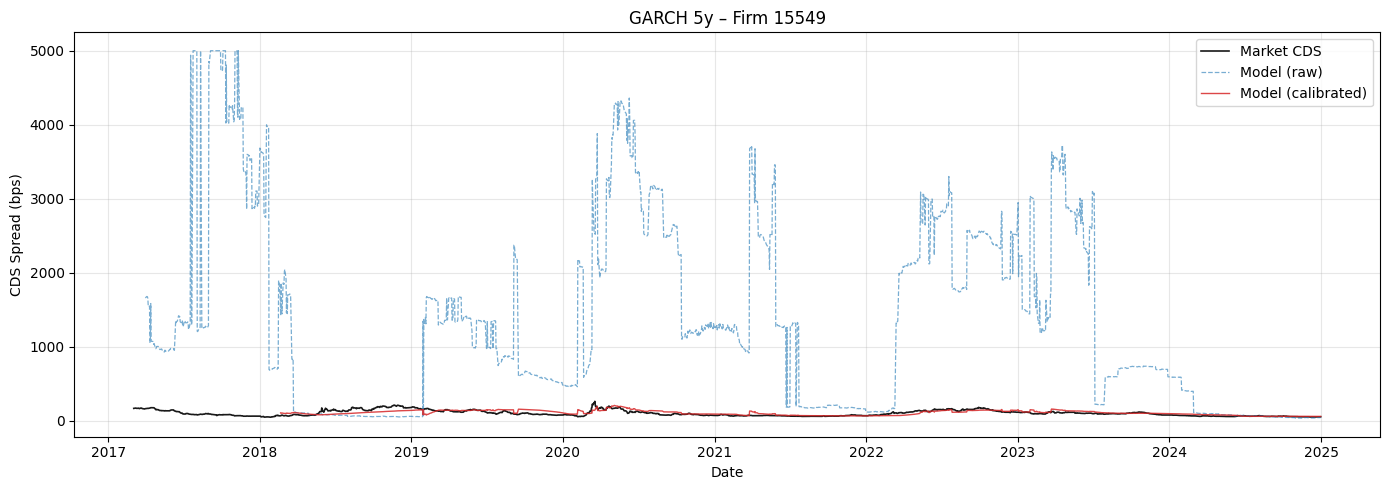

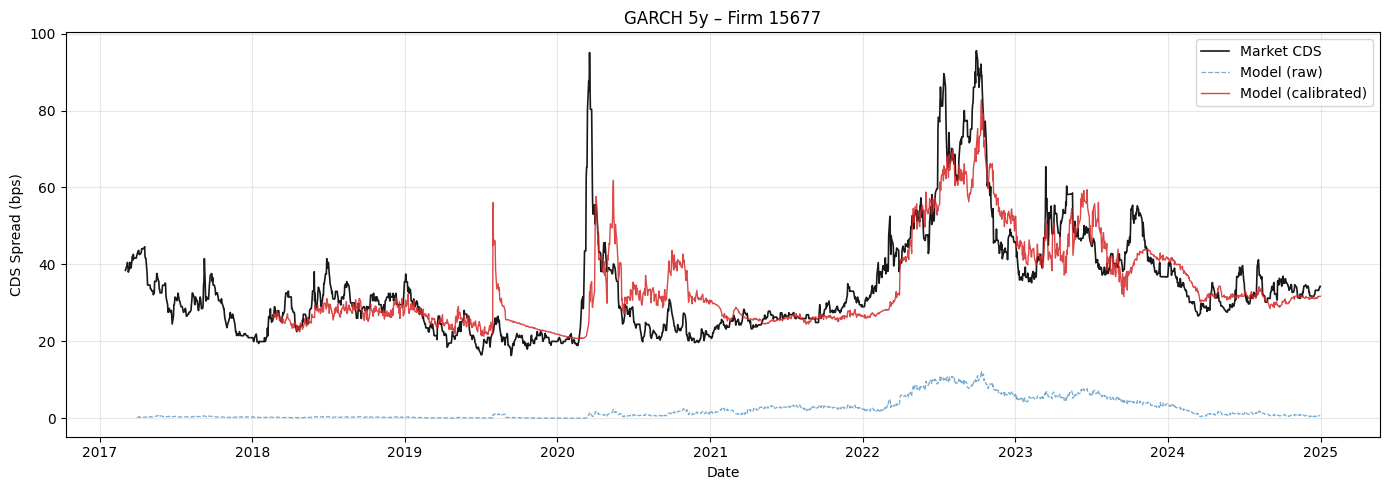

In [7]:
# Pick the first available model and the 5y maturity for illustration
demo_model = list(all_results.keys())[0]
demo_mat   = '5y'
demo_df    = all_results[demo_model][demo_mat]

# Select up to 4 firms with the most calibrated observations
firm_counts = demo_df.dropna(subset=['calibrated']).groupby('gvkey').size().sort_values(ascending=False)
top_firms   = firm_counts.head(4).index.tolist()

print(f'Showing {demo_model} {demo_mat} for firms: {top_firms}\n')

for gvkey in top_firms:
    plot_timeseries(
        demo_df, gvkey,
        title=f'{demo_model} {demo_mat} – Firm {gvkey}',
        save_path=str(CALIB_DIR / f'timeseries_{demo_model.lower().replace("-","_")}_{demo_mat}_{gvkey}.png'),
    )

---
## 6. Rolling Calibration Parameters (β₀, β₁) Over Time

Shows how the intercept and slope of the affine calibration evolve.
- A **β₁ ≈ 1 and β₀ ≈ 0** means the model is already well-calibrated.
- A **β₁ far from 1** suggests the model systematically over- or under-estimates spread sensitivity.
- A **large β₀** captures a constant level offset.

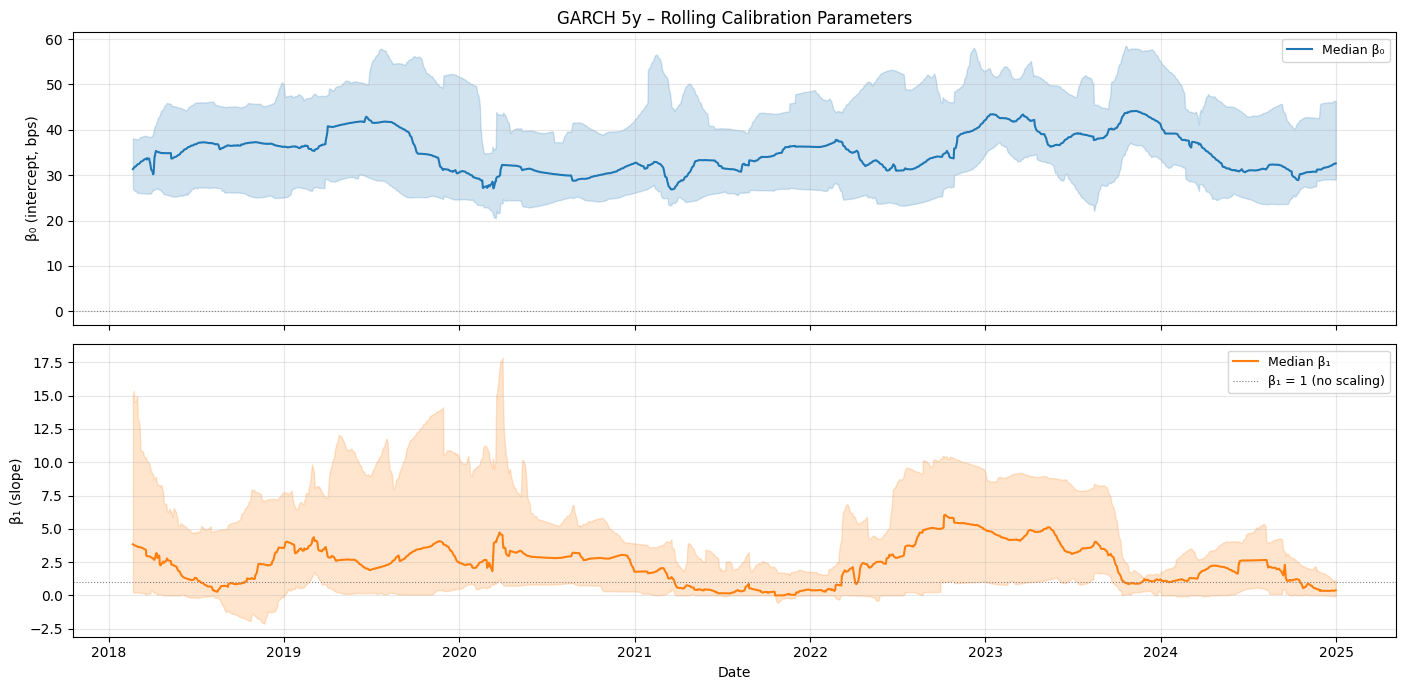

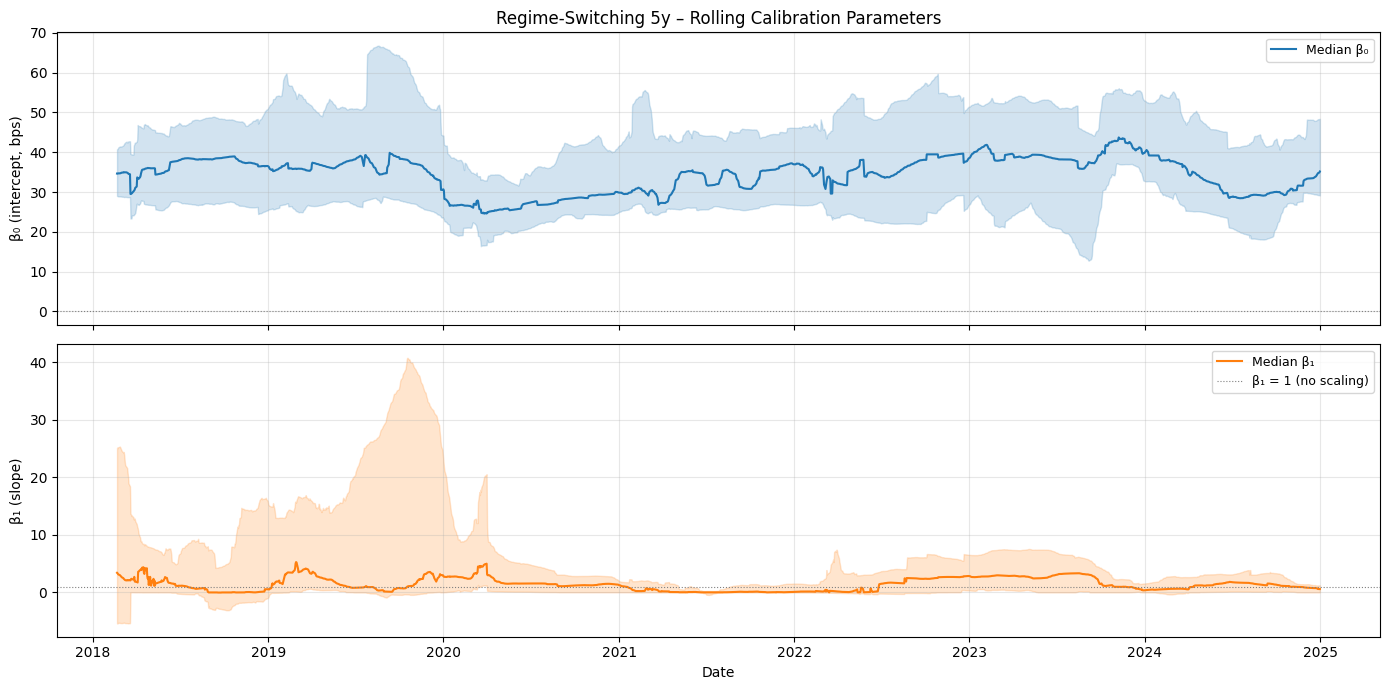

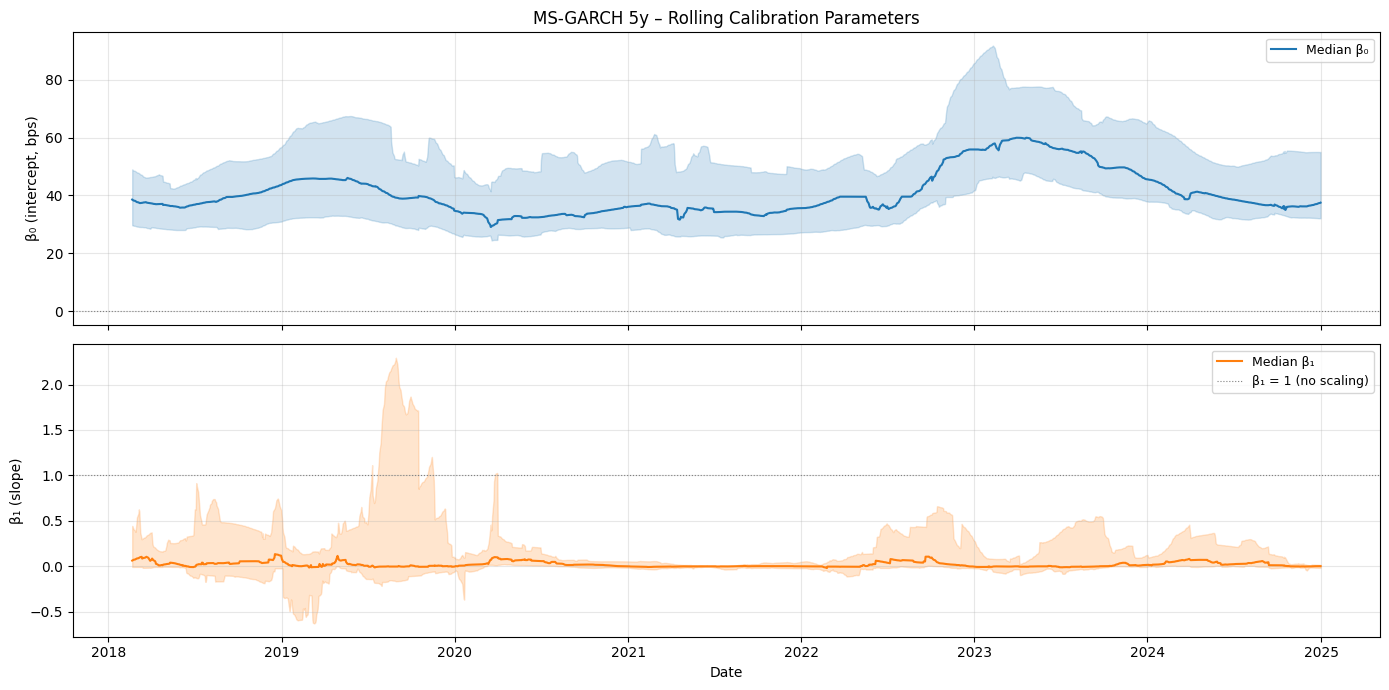

In [8]:
for model_name, results in all_results.items():
    for mat_key in ['5y']:
        if mat_key in results:
            plot_rolling_betas(
                results[mat_key],
                model_name=model_name,
                maturity=mat_key,
                save_path=str(CALIB_DIR / f'betas_{model_name.lower().replace("-","_")}_{mat_key}.png'),
            )

---
## 7. Firm-Level Metrics

Breakdown of RMSE and correlation improvements per firm (5-year maturity).

In [9]:
for model_name, results in all_results.items():
    if '5y' not in results:
        continue
    firm_metrics = compute_firm_level_metrics(results['5y'])
    firm_metrics = firm_metrics.sort_values('rmse_calibrated')

    print(f'\n{"="*60}')
    print(f'  {model_name} – 5Y Firm-Level Metrics')
    print(f'{"="*60}')

    display_cols_firm = ['company', 'n_obs', 'rmse_raw', 'rmse_calibrated',
                         'corr_levels_raw', 'corr_levels_cal',
                         'corr_changes_raw', 'corr_changes_cal']
    display_cols_firm = [c for c in display_cols_firm if c in firm_metrics.columns]
    display(firm_metrics[display_cols_firm].round(4))

    # Save
    fname = f'firm_metrics_{model_name.lower().replace("-","_")}_5y.csv'
    firm_metrics.to_csv(CALIB_DIR / fname, index=False)
    print(f'Saved to {CALIB_DIR / fname}')


  GARCH – 5Y Firm-Level Metrics


,company,n_obs,rmse_raw,rmse_calibrated,corr_levels_raw,corr_levels_cal,corr_changes_raw,corr_changes_cal
20,WOLTERS KLUWER NV,802,33.3640,5.0680,0.3015,0.7688,-0.0075,0.0020
28,DEUTSCHE POST AG,1791,27.2981,5.3601,0.5652,0.7809,0.1978,0.2084
0,LVMH MOET HENNESSY,1791,29.7256,5.8319,0.4368,0.7528,0.0668,0.0063
19,SANOFI SA,1791,30.3016,6.0174,0.0919,0.7557,0.0014,-0.0548
27,KERING SA,1791,32.3712,7.0128,0.3222,0.7347,0.1021,0.0932
8,DANONE SA,1791,38.1075,7.0167,0.6851,0.8559,0.0481,0.0760
24,ORANGE S.A.,1791,42.7603,7.1249,0.2958,0.6240,0.1623,0.1046
5,ALLIANZ SE,1791,24.2944,7.6248,0.6864,0.8790,0.3412,0.2826
4,MUNICH REINSURANCE,1791,33.5674,7.9123,0.7979,0.8239,0.2046,0.1875
18,AIR LIQUIDE SA,1620,31.7619,7.9207,0.2459,0.6581,0.0066,0.0066


Saved to c:\Users\Chase\Downloads\Seminar QF\Seminar QF\data\output\calibration\firm_metrics_garch_5y.csv

  Regime-Switching – 5Y Firm-Level Metrics


,company,n_obs,rmse_raw,rmse_calibrated,corr_levels_raw,corr_levels_cal,corr_changes_raw,corr_changes_cal
20,WOLTERS KLUWER NV,273,33.3869,4.4643,0.1465,0.7061,-0.0071,0.1560
28,DEUTSCHE POST AG,1791,28.3727,5.0697,0.4991,0.8194,0.2570,0.2407
0,LVMH MOET HENNESSY,1791,30.1650,5.3577,0.3102,0.7821,0.1655,0.1887
9,SIEMENS AG,1791,31.3632,5.8579,0.8853,0.9105,0.3351,0.3087
19,SANOFI SA,1791,30.3032,5.8857,-0.1947,0.7651,0.0119,-0.0352
26,DEUTSCHE TELEKOM AG,1791,41.8430,6.3503,-0.1177,0.7158,0.0240,0.1406
27,KERING SA,1771,33.4325,6.8121,0.3072,0.7964,0.1055,0.1736
8,DANONE SA,1771,38.1350,6.8788,0.7201,0.8676,0.0107,-0.0244
24,ORANGE S.A.,1791,40.4319,7.6687,-0.0890,0.5655,0.0516,0.0517
18,AIR LIQUIDE SA,1667,31.8079,8.2438,0.1794,0.5579,0.0151,0.0054


Saved to c:\Users\Chase\Downloads\Seminar QF\Seminar QF\data\output\calibration\firm_metrics_regime_switching_5y.csv

  MS-GARCH – 5Y Firm-Level Metrics


,company,n_obs,rmse_raw,rmse_calibrated,corr_levels_raw,corr_levels_cal,corr_changes_raw,corr_changes_cal
0,LVMH MOET HENNESSY,1791,27.2450,7.8490,0.1731,0.4541,0.1455,0.0233
27,KERING SA,1791,76.4240,8.3781,0.2468,0.5626,0.0582,0.0156
19,SANOFI SA,1791,37.2028,9.3552,-0.0553,0.6114,0.0204,0.0094
18,AIR LIQUIDE SA,1702,159.7238,9.7622,0.1415,0.4002,-0.0011,0.0475
28,DEUTSCHE POST AG,1791,146.4329,11.1015,0.1903,0.2759,-0.0256,-0.0006
5,ALLIANZ SE,1791,159.9376,11.4587,-0.0468,0.4936,0.0067,0.0093
1,BNP PARIBAS SA,1791,2253.4047,11.5190,0.1845,0.5471,0.0225,0.0073
17,"IBERDROLA, S.A.",1791,49.2447,11.9696,0.1917,0.5672,0.0381,-0.0543
9,SIEMENS AG,1791,35.9837,12.1220,0.1909,0.5750,0.0929,0.0619
8,DANONE SA,1737,39.8150,12.4821,0.0785,0.6002,-0.0213,-0.0479


Saved to c:\Users\Chase\Downloads\Seminar QF\Seminar QF\data\output\calibration\firm_metrics_ms_garch_5y.csv


---
## 8. Save Calibrated Spreads

Export the calibrated spread data for downstream analysis.

In [10]:
for model_name, results in all_results.items():
    for mat_key, cal_df in results.items():
        fname = f'calibrated_spreads_{model_name.lower().replace("-","_")}_{mat_key}.csv'
        cal_df.to_csv(CALIB_DIR / fname, index=False)
        n = cal_df['calibrated'].notna().sum()
        print(f'  {model_name} {mat_key}: saved {n:,} calibrated obs → {fname}')

print(f'\n✓ All calibrated spreads saved to {CALIB_DIR}')

  GARCH 1y: saved 22,151 calibrated obs → calibrated_spreads_garch_1y.csv
  GARCH 3y: saved 41,896 calibrated obs → calibrated_spreads_garch_3y.csv
  GARCH 5y: saved 46,497 calibrated obs → calibrated_spreads_garch_5y.csv
  Regime-Switching 1y: saved 21,823 calibrated obs → calibrated_spreads_regime_switching_1y.csv
  Regime-Switching 3y: saved 40,146 calibrated obs → calibrated_spreads_regime_switching_3y.csv
  Regime-Switching 5y: saved 45,635 calibrated obs → calibrated_spreads_regime_switching_5y.csv
  MS-GARCH 1y: saved 29,303 calibrated obs → calibrated_spreads_ms_garch_1y.csv
  MS-GARCH 3y: saved 43,488 calibrated obs → calibrated_spreads_ms_garch_3y.csv
  MS-GARCH 5y: saved 47,247 calibrated obs → calibrated_spreads_ms_garch_5y.csv

✓ All calibrated spreads saved to c:\Users\Chase\Downloads\Seminar QF\Seminar QF\data\output\calibration


---
## 9. Mean & Median Calibrated Spreads vs Market

For each model and maturity, we aggregate the cross-section of firms each day (mean and median) and compare calibrated model spreads against market CDS spreads.  This directly mirrors the plots from the `visualize_results` notebook but now includes the calibrated series.

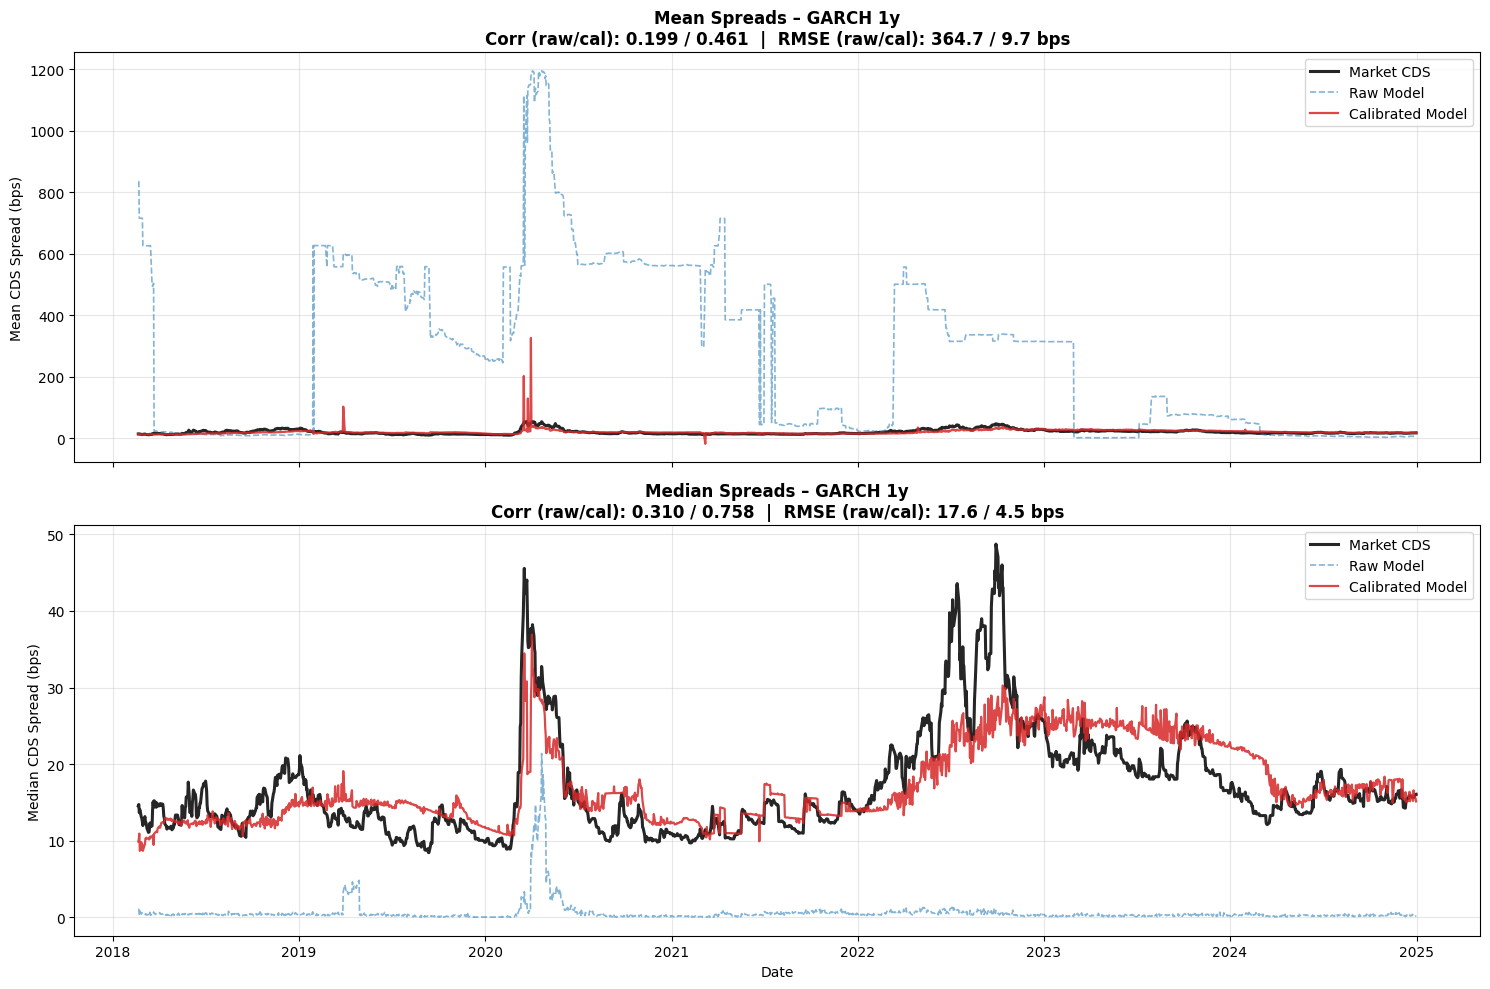

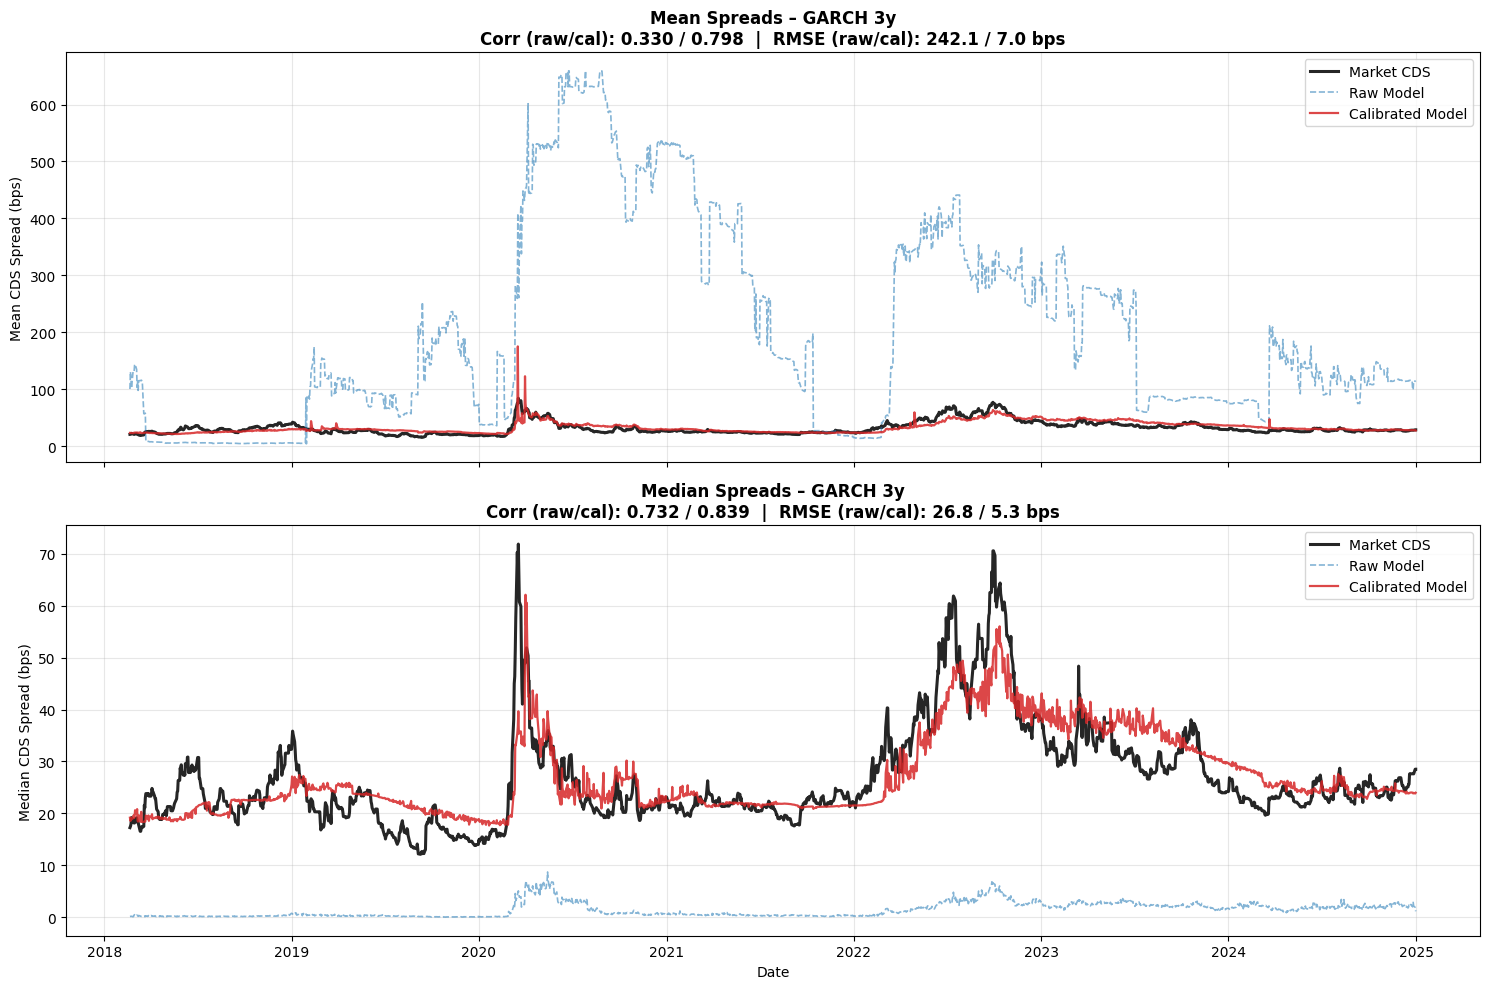

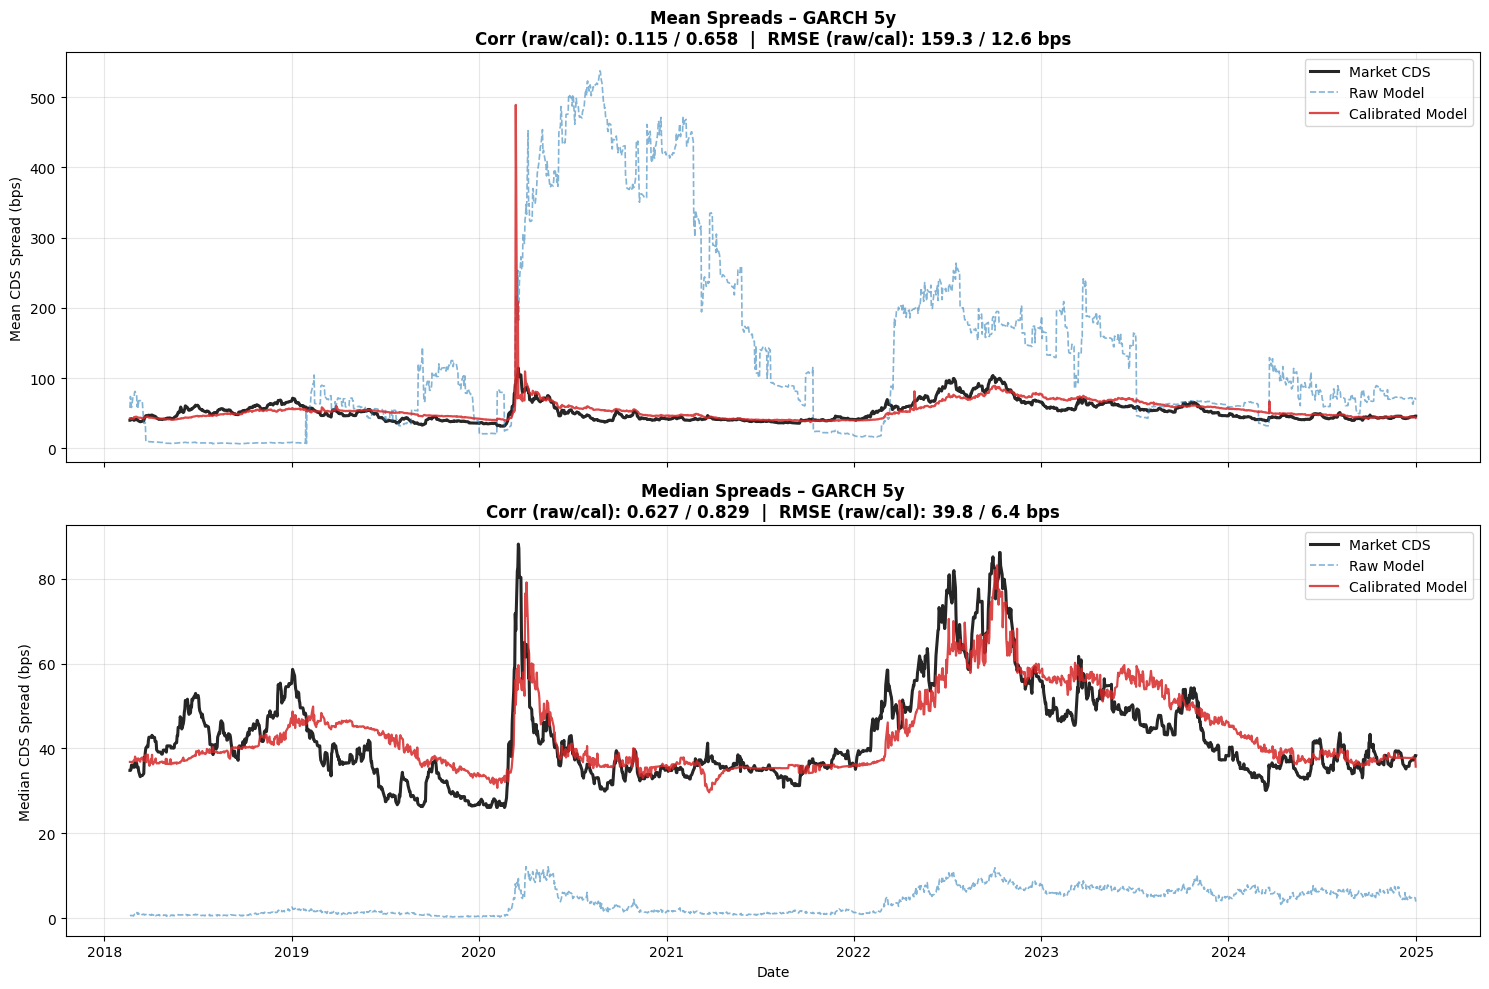

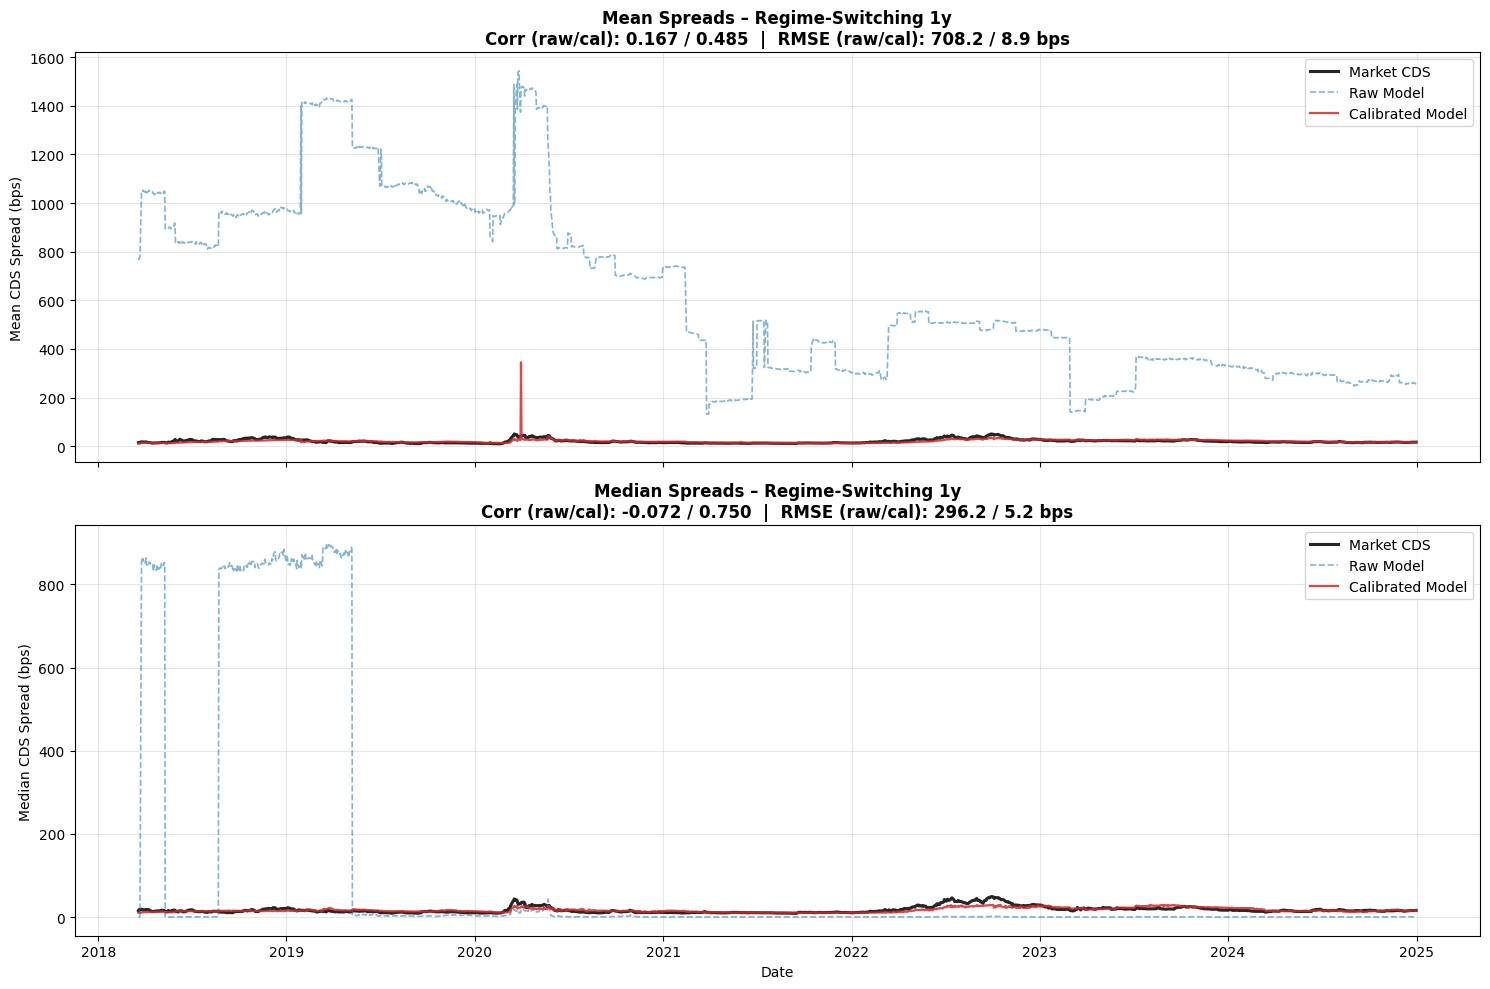

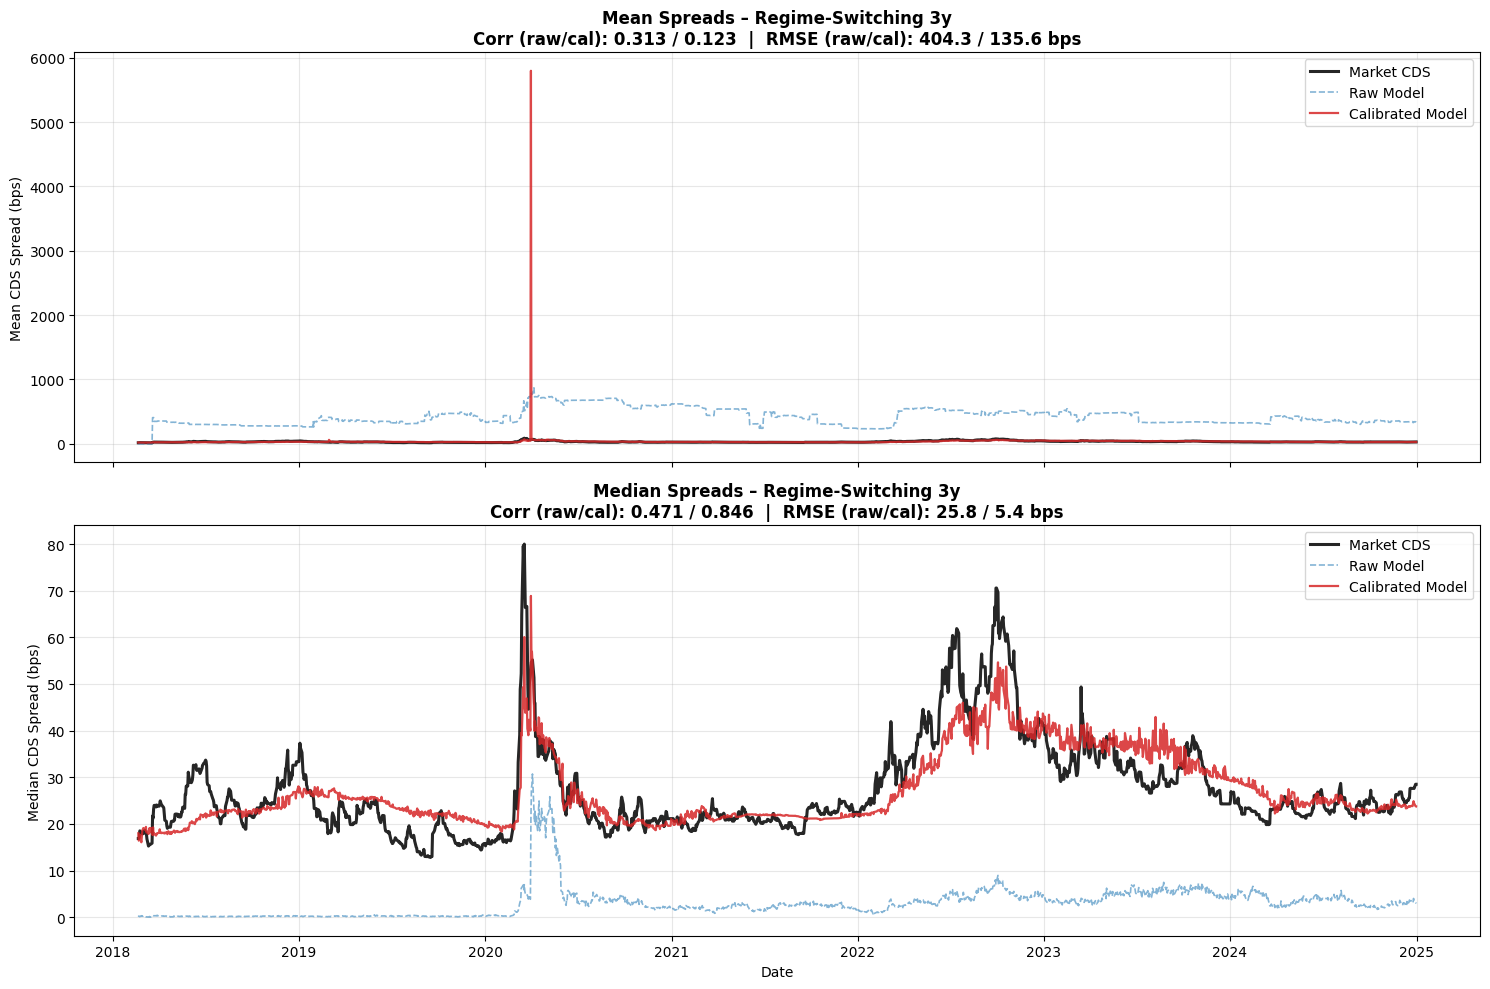

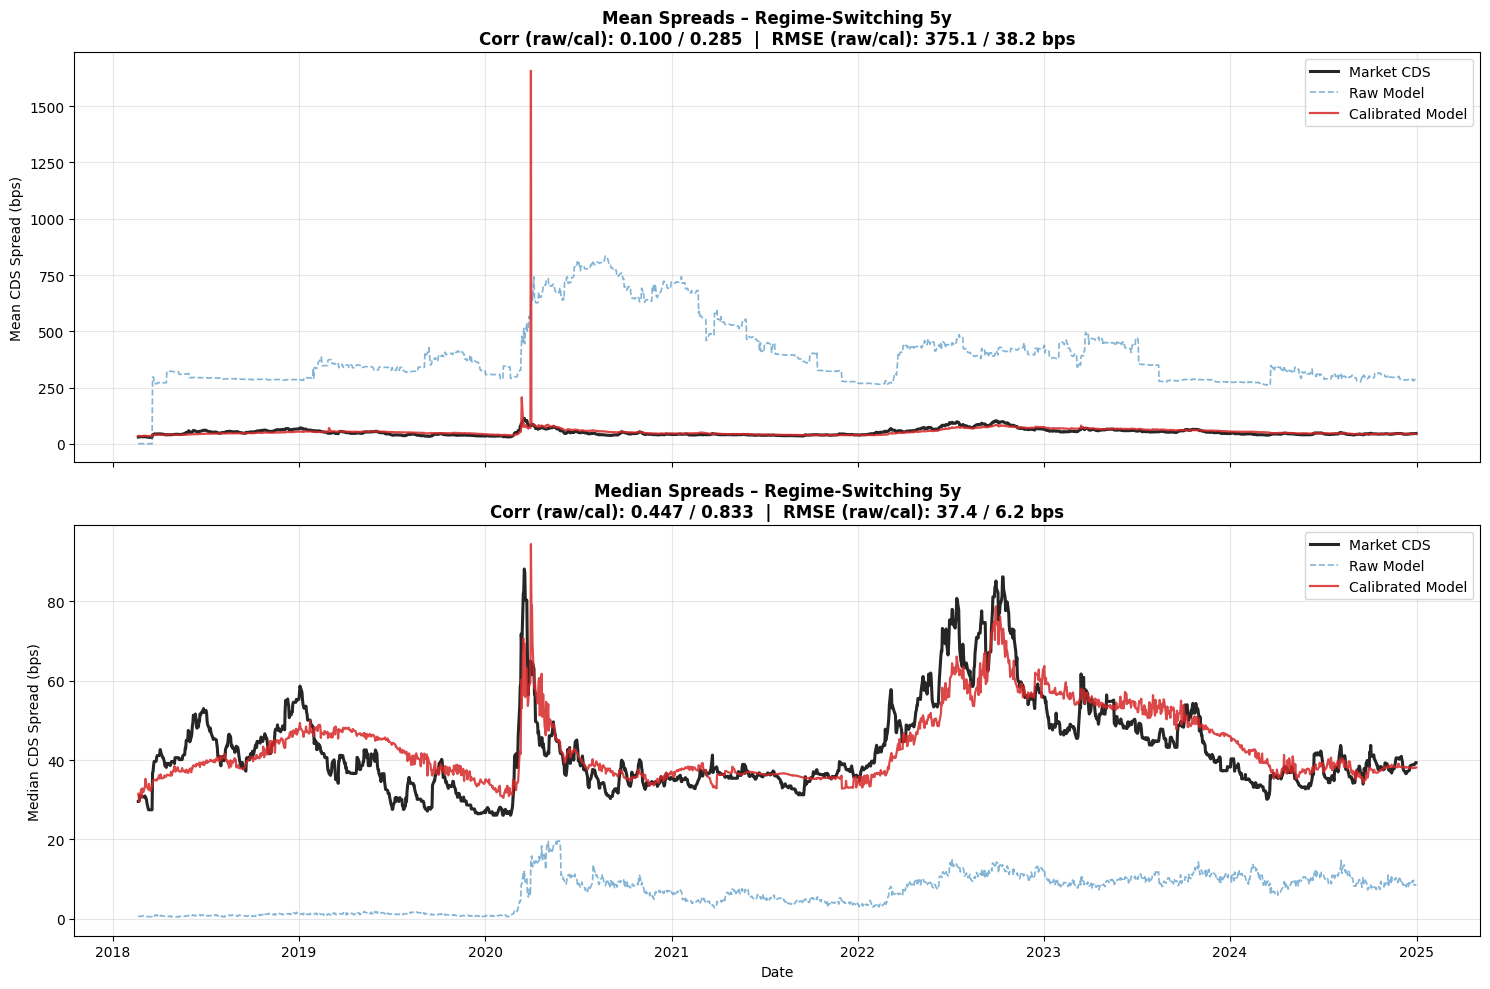

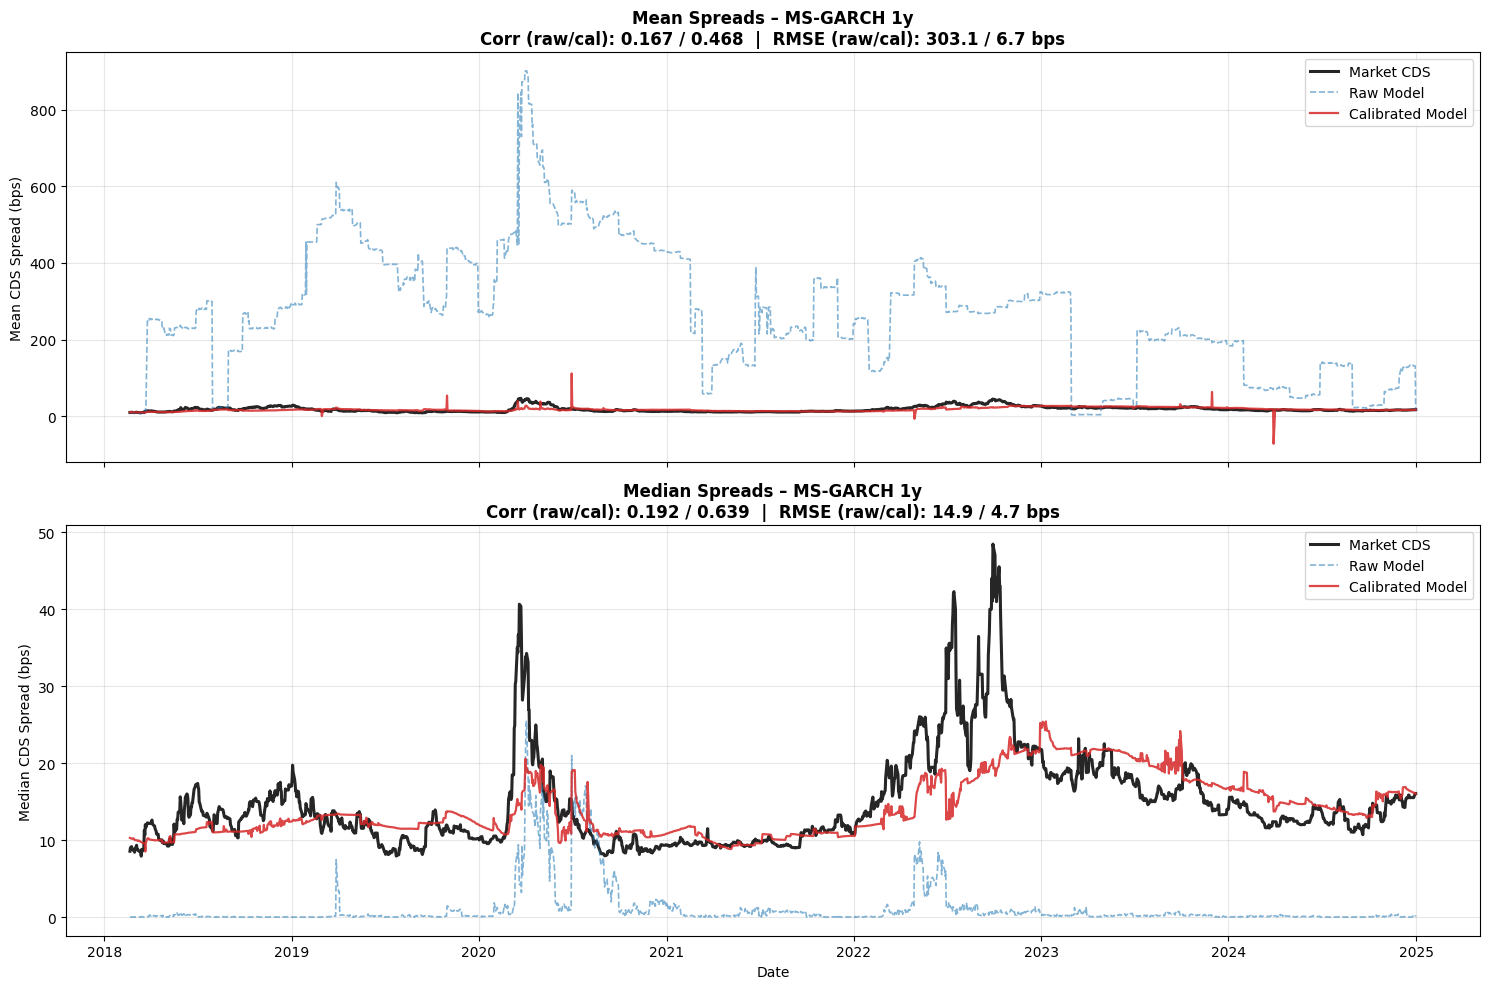

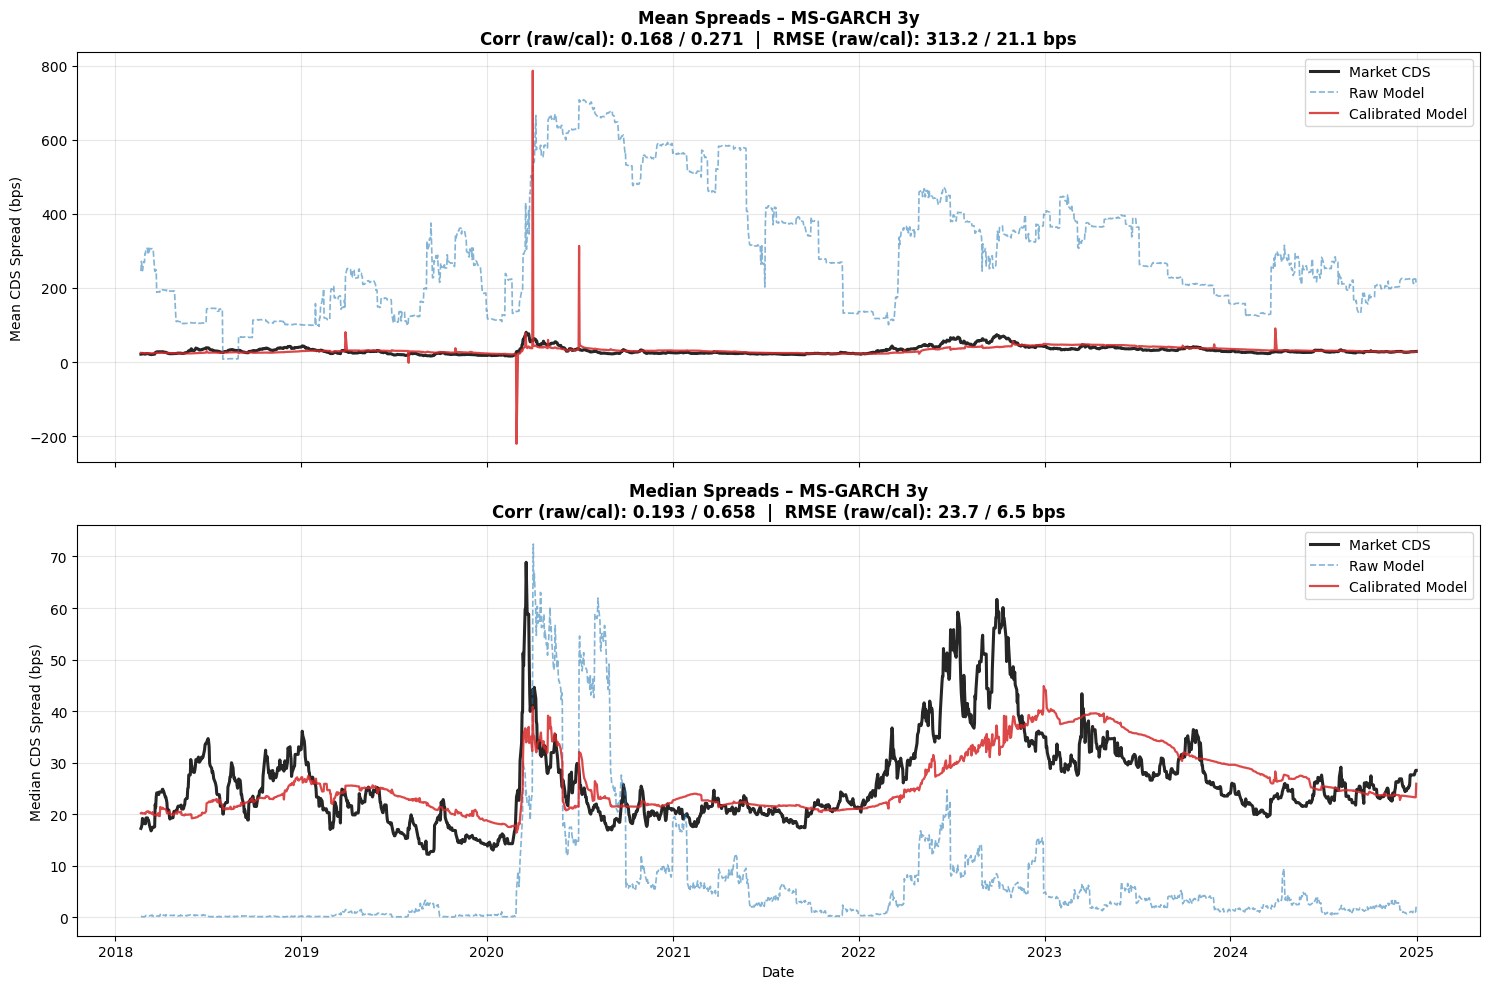

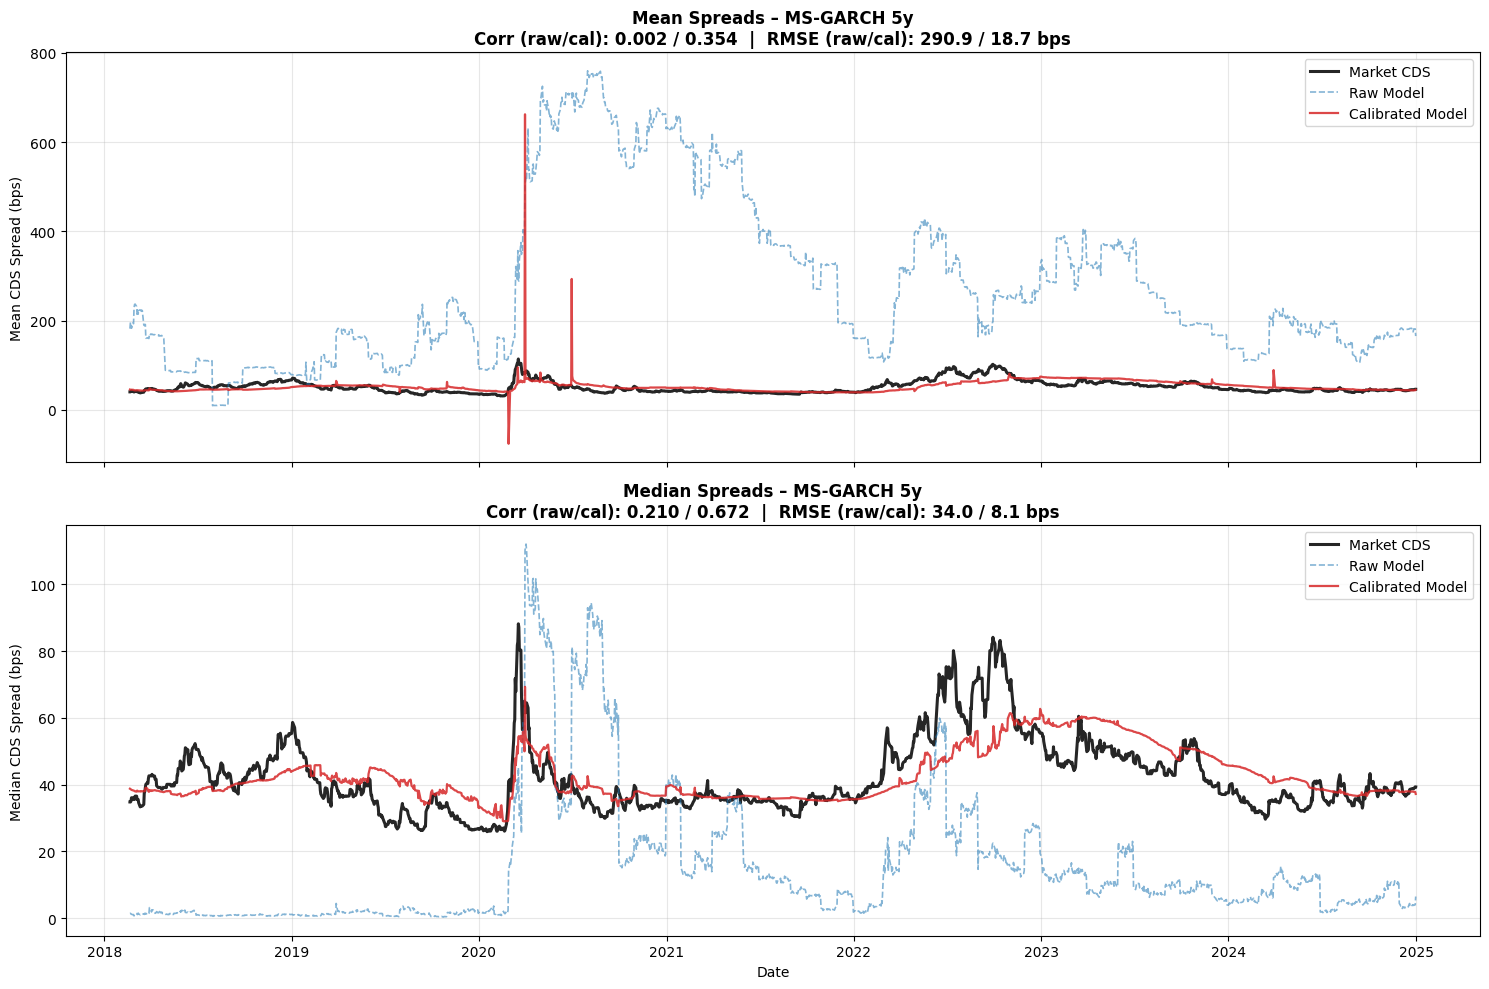

In [11]:
for model_name, results in all_results.items():
    for mat_key in ['1y', '3y', '5y']:
        if mat_key in results:
            plot_mean_median_vs_market(
                results[mat_key],
                model_name=model_name,
                maturity=mat_key,
                save_path=str(CALIB_DIR / f'mean_median_{model_name.lower().replace("-","_")}_{mat_key}.png'),
            )

---
## 10. Mean & Median Calibrated Spreads by Leverage Group

Split firms into low / medium / high leverage terciles (using debt-to-equity from the Merton file) and compare the cross-sectional mean and median of market vs calibrated spreads within each group.

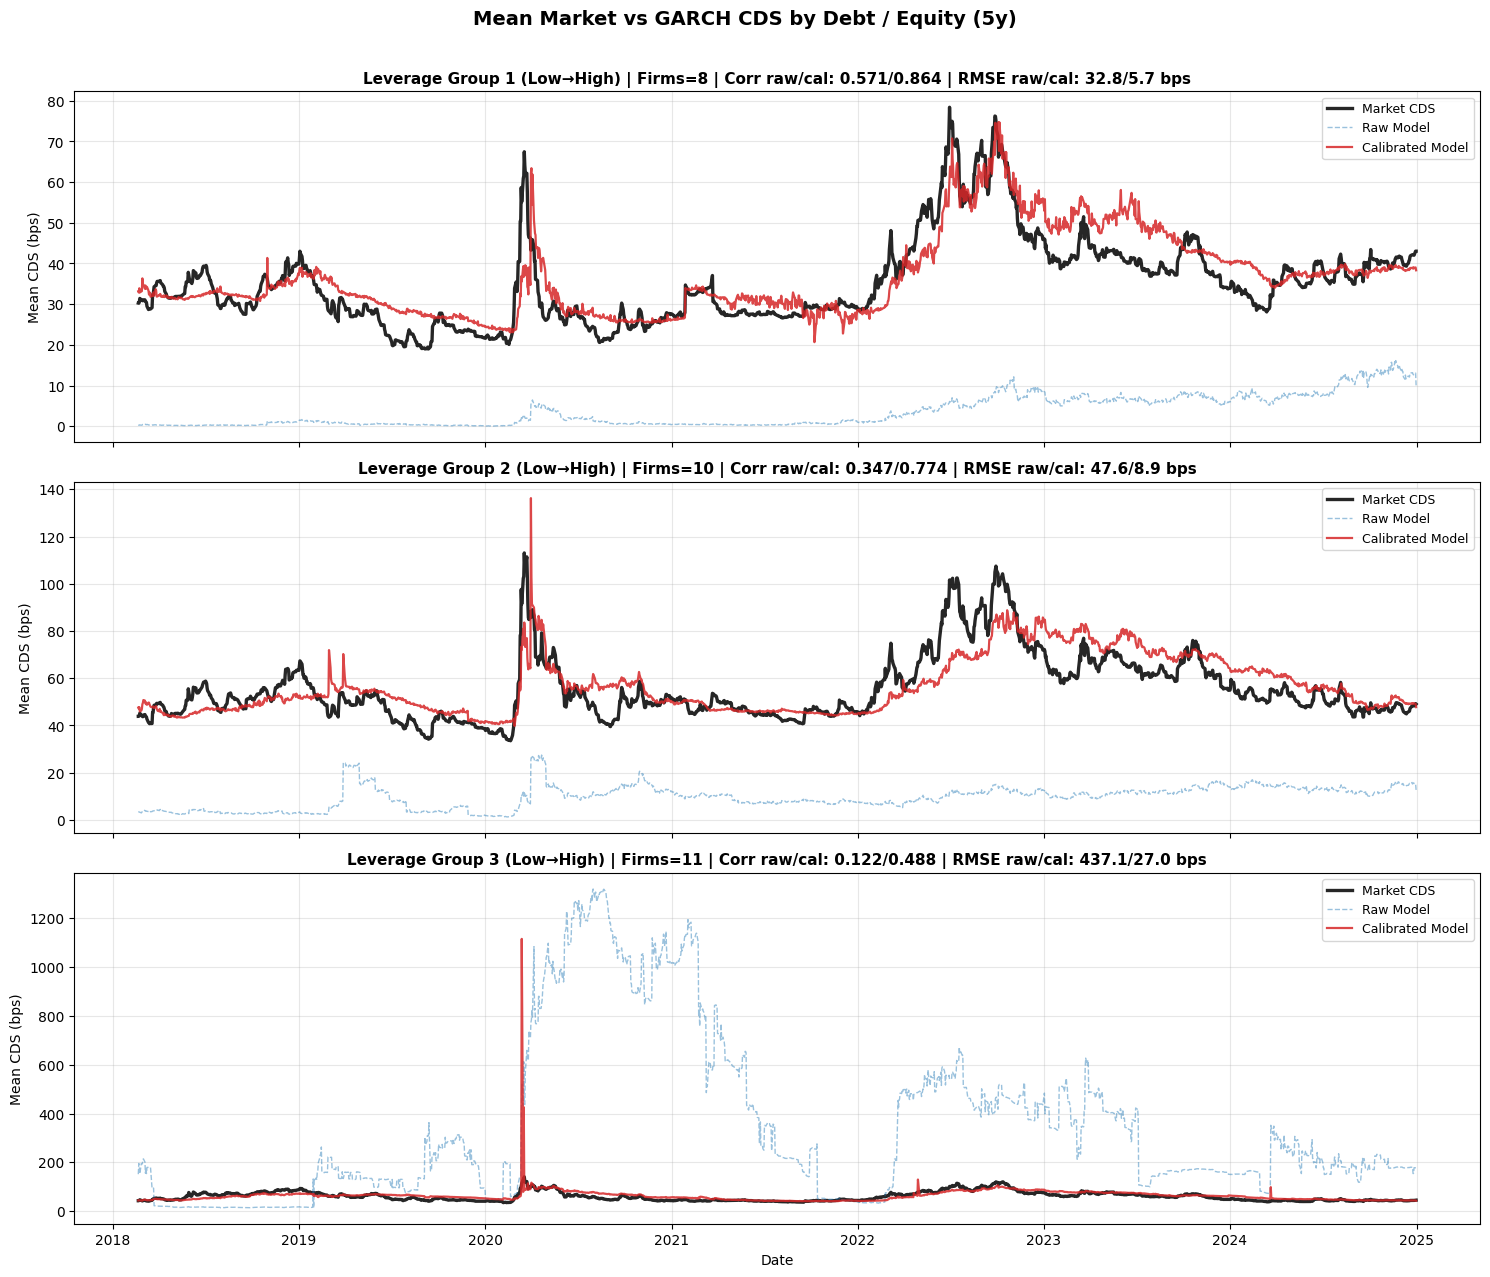


Firm membership (Debt / Equity):

  Leverage Group 1 (Low→High)  (8 firms)
    gvkey=14447  LVMH MOET HENNESSY                   leverage=0.2898
    gvkey=221244  ADIDAS AG                            leverage=0.3514
    gvkey=222379  KERING SA                            leverage=0.4103
    gvkey=101202  AIR LIQUIDE SA                       leverage=0.4321
    gvkey=101204  SANOFI SA                            leverage=0.4532
    gvkey=101361  WOLTERS KLUWER NV                    leverage=0.4883
    gvkey=17452  DANONE SA                            leverage=0.6188
    gvkey=17436  BASF SE                              leverage=0.6943

  Leverage Group 2 (Low→High)  (10 firms)
    gvkey=100080  BAYER AG                             leverage=0.7065
    gvkey=23667  KON AHOLD DELHAIZE                   leverage=0.8094
    gvkey=241456  DEUTSCHE POST AG                     leverage=0.8523
    gvkey=19349  SIEMENS AG                           leverage=0.9223
    gvkey=23671  NOKIA OYJ        

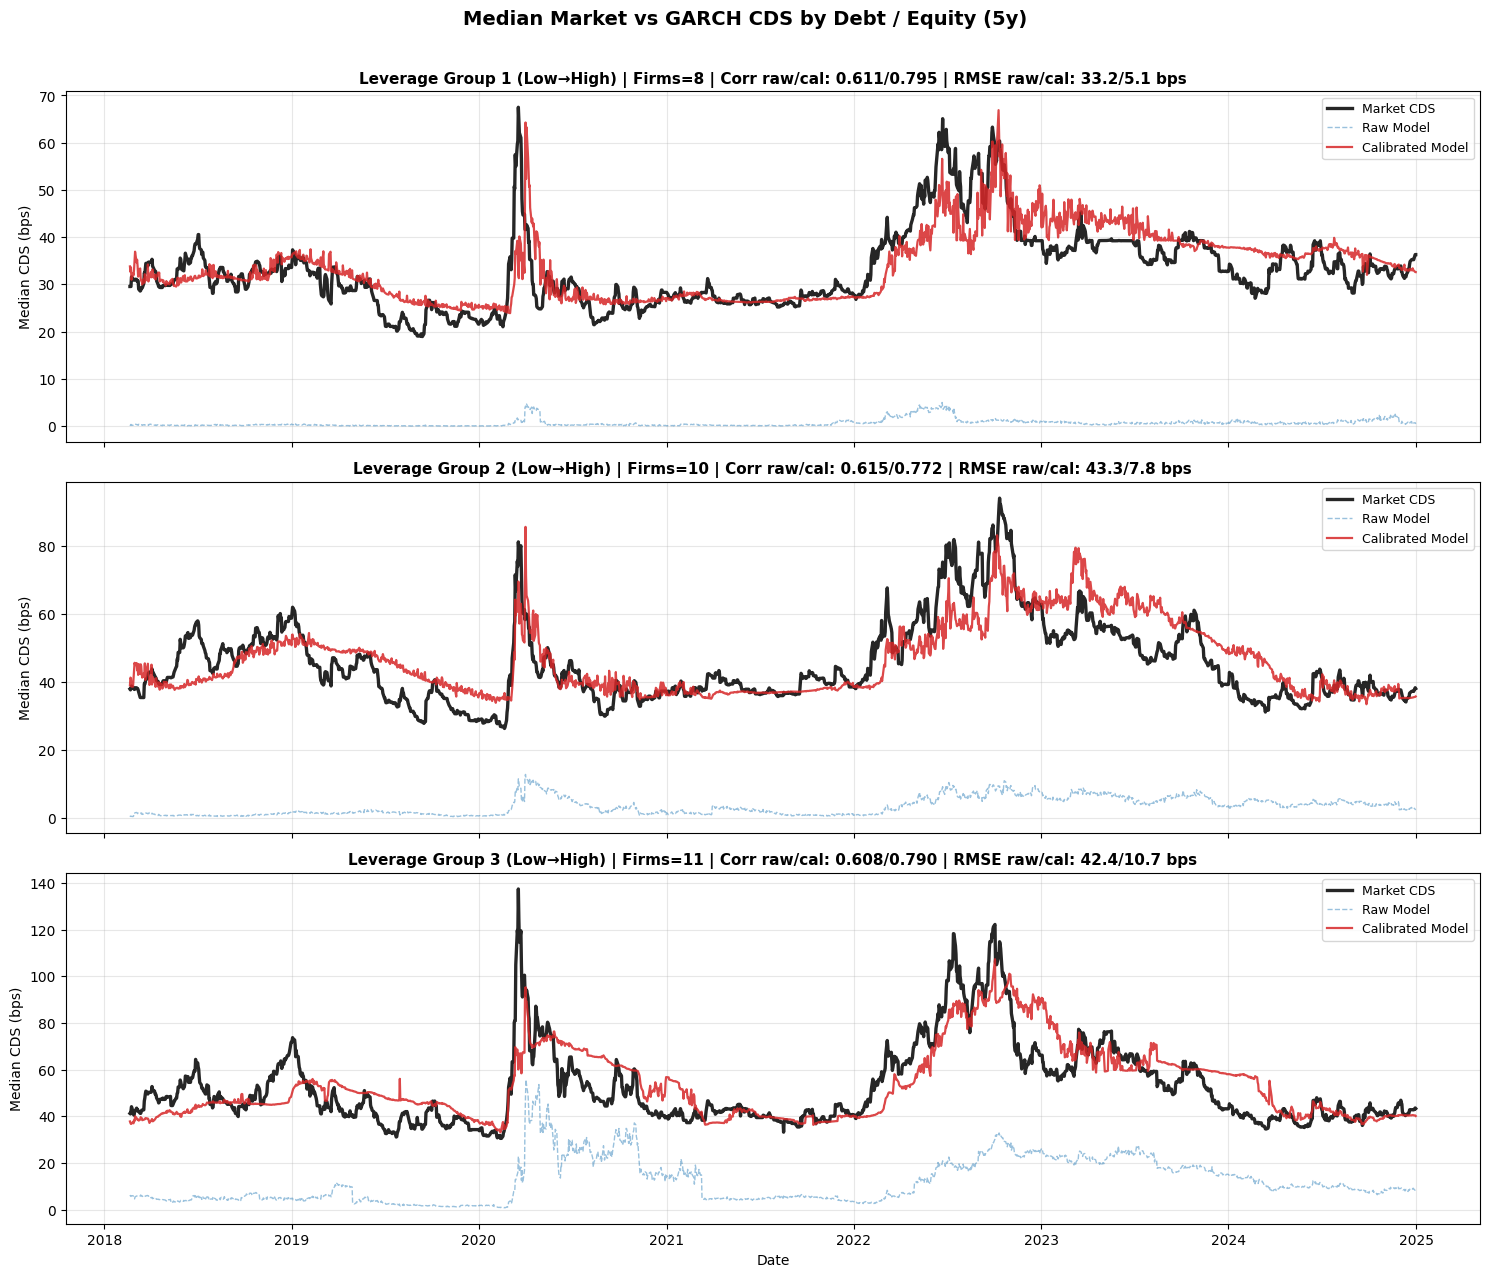


Firm membership (Debt / Equity):

  Leverage Group 1 (Low→High)  (8 firms)
    gvkey=14447  LVMH MOET HENNESSY                   leverage=0.2898
    gvkey=221244  ADIDAS AG                            leverage=0.3514
    gvkey=222379  KERING SA                            leverage=0.4103
    gvkey=101202  AIR LIQUIDE SA                       leverage=0.4321
    gvkey=101204  SANOFI SA                            leverage=0.4532
    gvkey=101361  WOLTERS KLUWER NV                    leverage=0.4883
    gvkey=17452  DANONE SA                            leverage=0.6188
    gvkey=17436  BASF SE                              leverage=0.6943

  Leverage Group 2 (Low→High)  (10 firms)
    gvkey=100080  BAYER AG                             leverage=0.7065
    gvkey=23667  KON AHOLD DELHAIZE                   leverage=0.8094
    gvkey=241456  DEUTSCHE POST AG                     leverage=0.8523
    gvkey=19349  SIEMENS AG                           leverage=0.9223
    gvkey=23671  NOKIA OYJ        

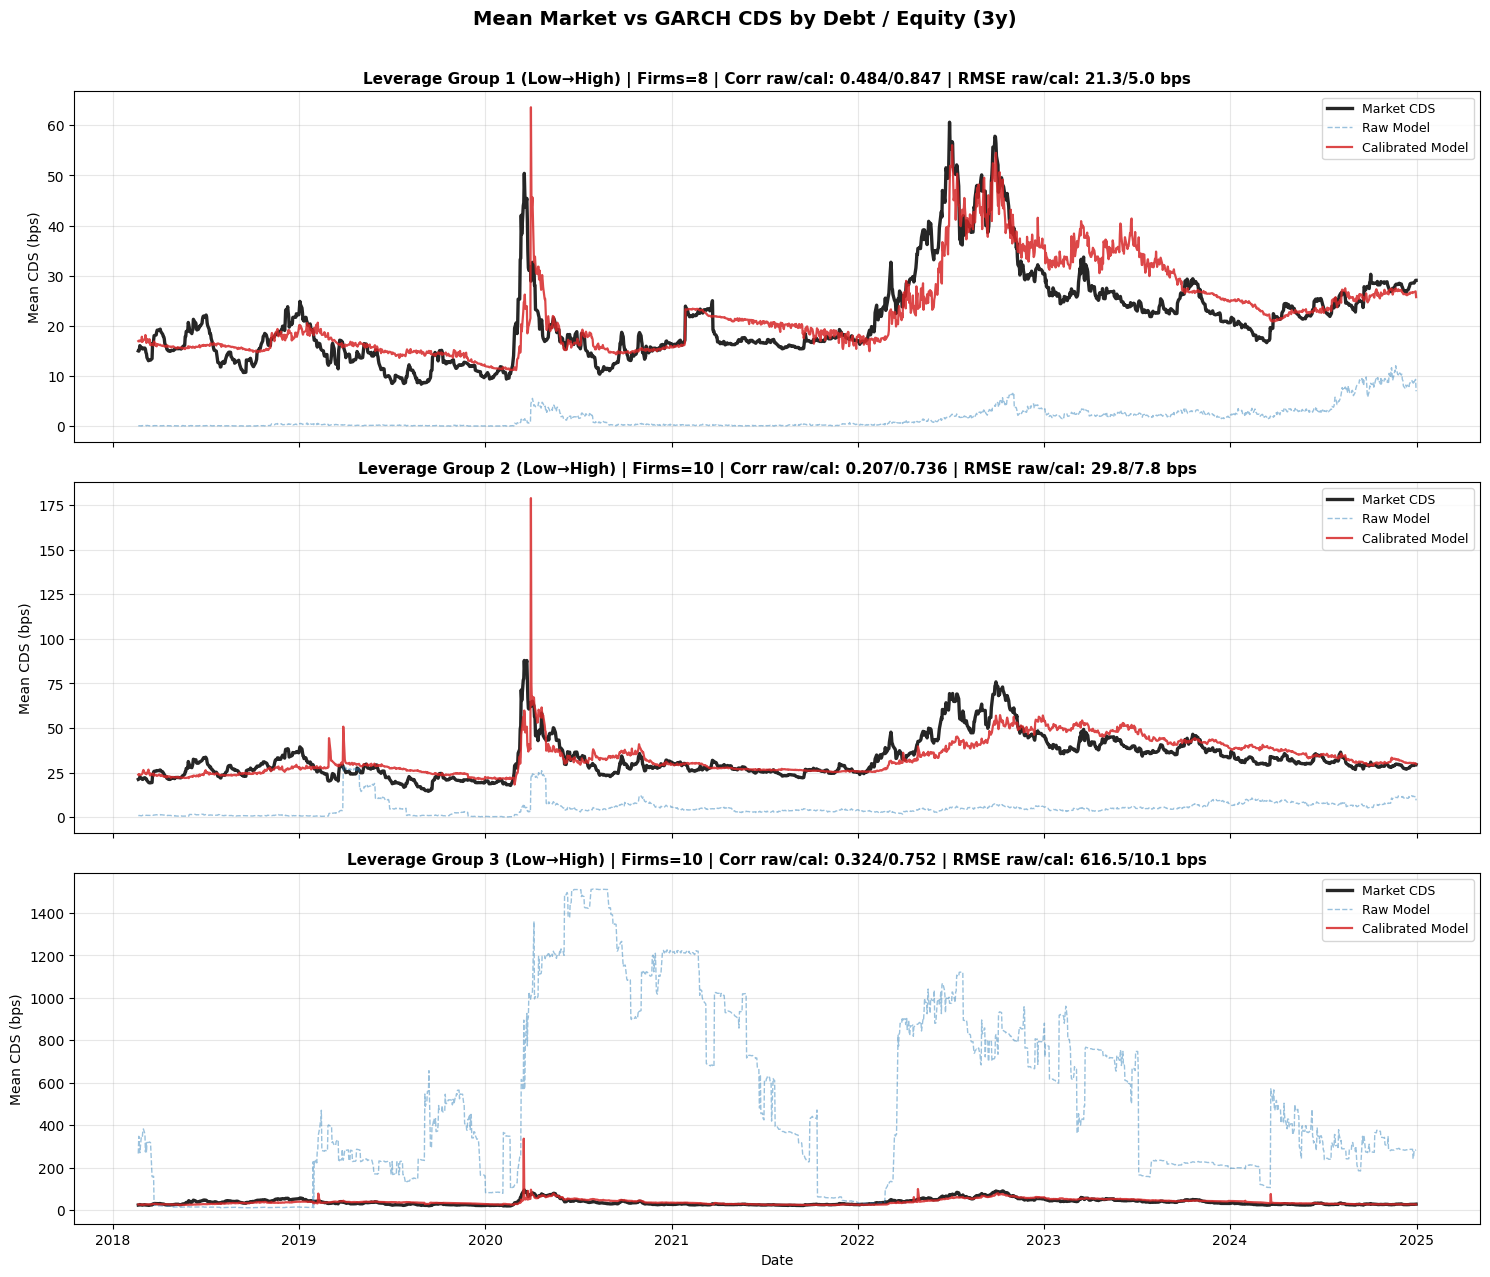


Firm membership (Debt / Equity):

  Leverage Group 1 (Low→High)  (8 firms)
    gvkey=14447  LVMH MOET HENNESSY                   leverage=0.2898
    gvkey=221244  ADIDAS AG                            leverage=0.3514
    gvkey=222379  KERING SA                            leverage=0.4103
    gvkey=101202  AIR LIQUIDE SA                       leverage=0.4321
    gvkey=101204  SANOFI SA                            leverage=0.4532
    gvkey=101361  WOLTERS KLUWER NV                    leverage=0.4883
    gvkey=17452  DANONE SA                            leverage=0.6188
    gvkey=17436  BASF SE                              leverage=0.6943

  Leverage Group 2 (Low→High)  (10 firms)
    gvkey=100080  BAYER AG                             leverage=0.7065
    gvkey=23667  KON AHOLD DELHAIZE                   leverage=0.8094
    gvkey=241456  DEUTSCHE POST AG                     leverage=0.8523
    gvkey=19349  SIEMENS AG                           leverage=0.9223
    gvkey=23671  NOKIA OYJ        

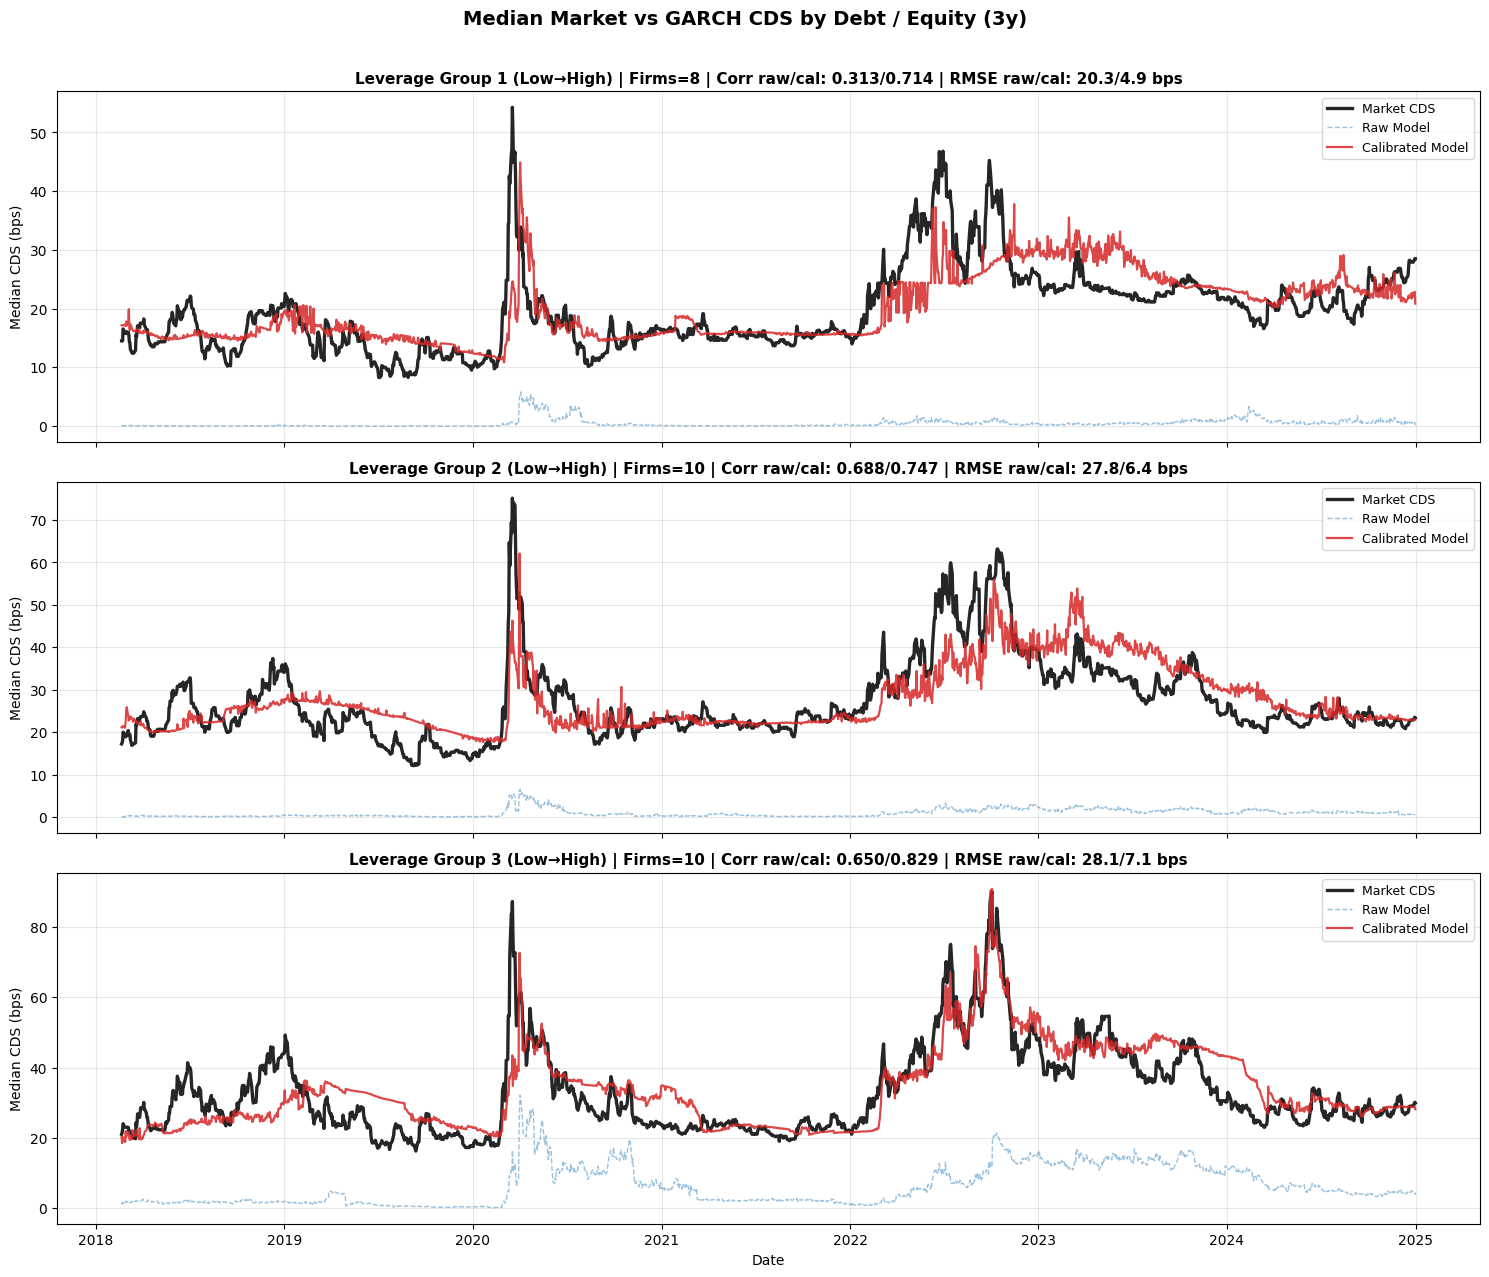


Firm membership (Debt / Equity):

  Leverage Group 1 (Low→High)  (8 firms)
    gvkey=14447  LVMH MOET HENNESSY                   leverage=0.2898
    gvkey=221244  ADIDAS AG                            leverage=0.3514
    gvkey=222379  KERING SA                            leverage=0.4103
    gvkey=101202  AIR LIQUIDE SA                       leverage=0.4321
    gvkey=101204  SANOFI SA                            leverage=0.4532
    gvkey=101361  WOLTERS KLUWER NV                    leverage=0.4883
    gvkey=17452  DANONE SA                            leverage=0.6188
    gvkey=17436  BASF SE                              leverage=0.6943

  Leverage Group 2 (Low→High)  (10 firms)
    gvkey=100080  BAYER AG                             leverage=0.7065
    gvkey=23667  KON AHOLD DELHAIZE                   leverage=0.8094
    gvkey=241456  DEUTSCHE POST AG                     leverage=0.8523
    gvkey=19349  SIEMENS AG                           leverage=0.9223
    gvkey=23671  NOKIA OYJ        

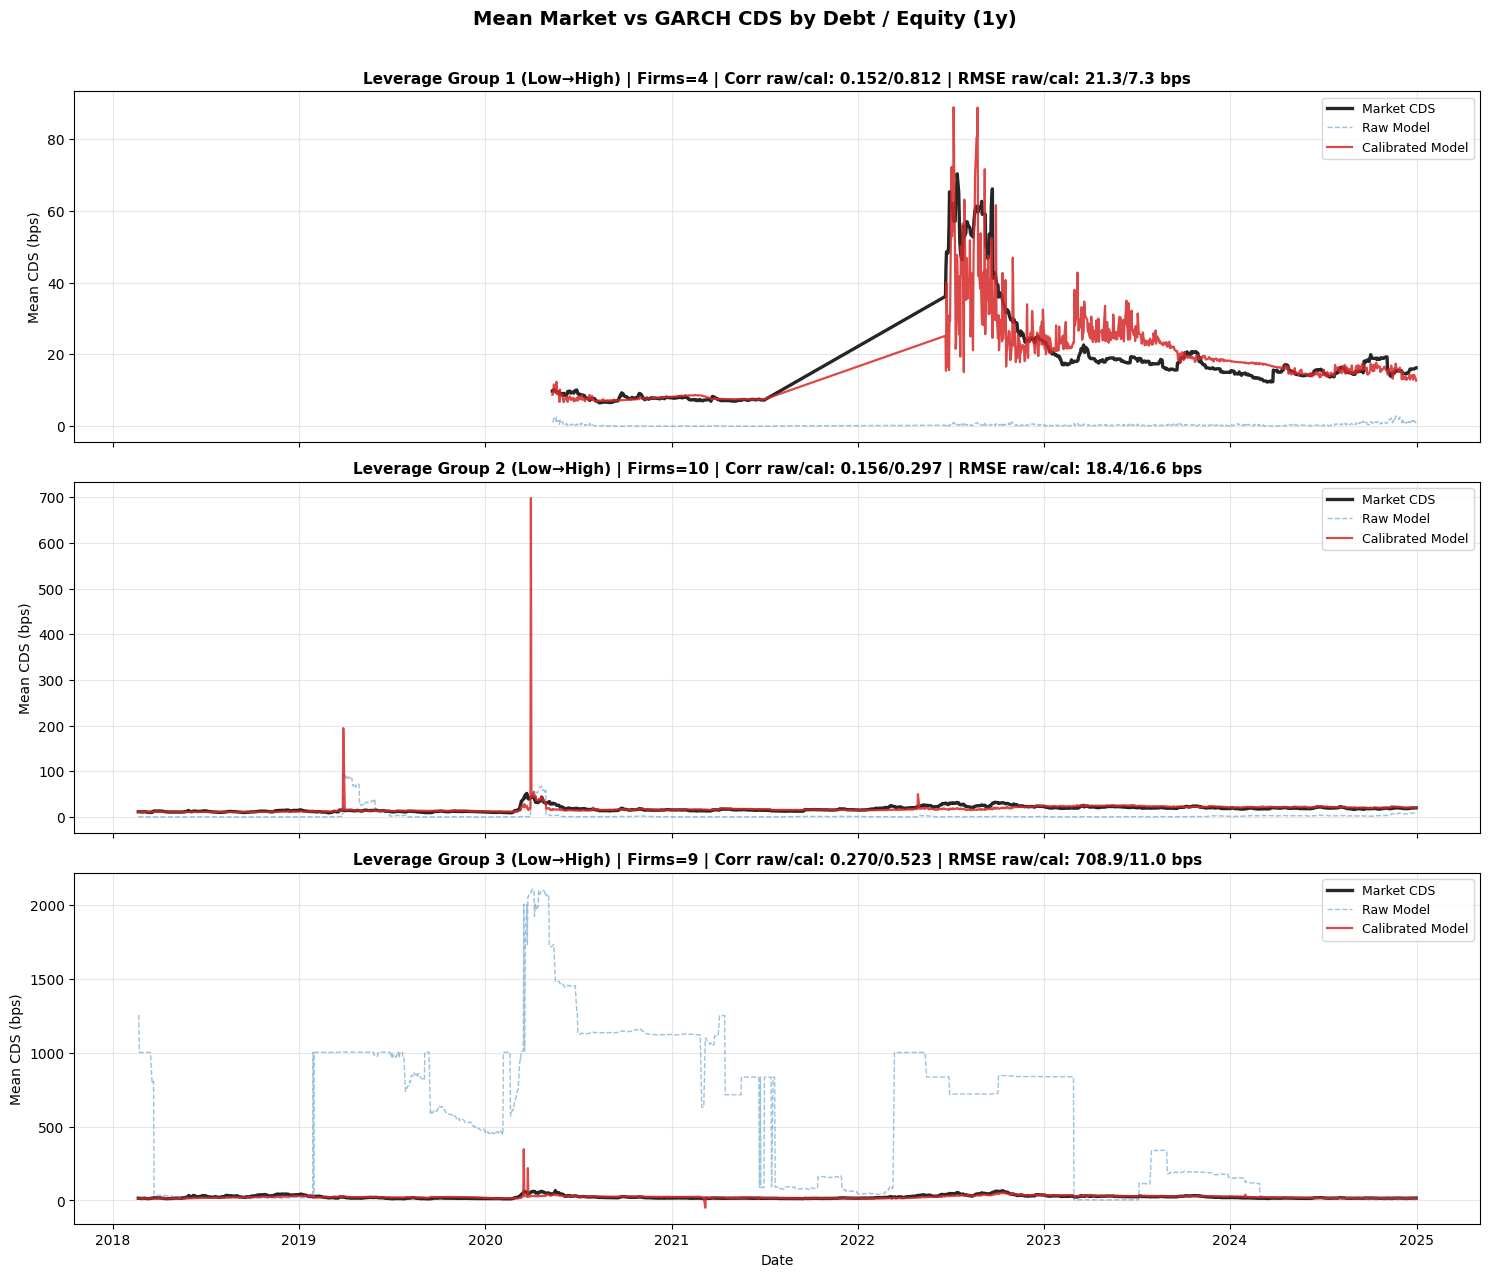


Firm membership (Debt / Equity):

  Leverage Group 1 (Low→High)  (4 firms)
    gvkey=14447  LVMH MOET HENNESSY                   leverage=0.2898
    gvkey=221244  ADIDAS AG                            leverage=0.3514
    gvkey=222379  KERING SA                            leverage=0.4103
    gvkey=17436  BASF SE                              leverage=0.6943

  Leverage Group 2 (Low→High)  (10 firms)
    gvkey=100080  BAYER AG                             leverage=0.7065
    gvkey=23667  KON AHOLD DELHAIZE                   leverage=0.8094
    gvkey=241456  DEUTSCHE POST AG                     leverage=0.8523
    gvkey=19349  SIEMENS AG                           leverage=0.9223
    gvkey=23671  NOKIA OYJ                            leverage=0.9334
    gvkey=24625  TOTALENERGIES SE                     leverage=1.1300
    gvkey=102296  VINCI                                leverage=1.3400
    gvkey=61616  ENI S.P.A.                           leverage=1.4535
    gvkey=100957  IBERDROLA, S.A.   

In [ ]:
# MERTON_FILE is already defined in the path-setup cell above

for model_name, results in all_results.items():
    for mat_key in ['5y', '3y', '1y']:
        if mat_key not in results:
            continue
        for agg in ['mean', 'median']:
            plot_mean_median_by_leverage(
                results[mat_key],
                merton_file=str(MERTON_FILE),
                model_name=model_name,
                maturity=mat_key,
                leverage_metric='debt_to_equity',
                n_groups=3,
                aggregation=agg,
                save_path=str(CALIB_DIR / f'leverage_{agg}_{model_name.lower().replace("-","_")}_{mat_key}.png'),
            )

---
## 9. Discussion

### How effective is the affine calibration?

Examine the metrics table above.  Key things to look for:

| Metric | What it tells you |
|---|---|
| **RMSE (raw → calibrated)** | If calibrated RMSE is substantially lower, the affine mapping captures the level/scale mismatch well. |
| **Correlation of levels** | Should stay the same or increase — the affine transform preserves rank ordering. |
| **Correlation of changes** | This is the harder test. If it doesn't improve, the model captures the *dynamics* about as well before calibration. |
| **β₁ ≈ 1, β₀ ≈ 0** | The model was already well-calibrated in that period. |
| **β₁ ≫ 1 or β₁ ≪ 1** | The model systematically under- or over-estimates the sensitivity of spreads to credit risk. |
| **Time-varying β** | If betas shift a lot, the model's calibration is regime-dependent — a possible limitation. |